<a href="https://colab.research.google.com/github/DanialNayyar/Machine-learning-foundations/blob/main/Mini-Projects/Breast_Cancer_Tumour_Classification/Notebook/Breast_Cancer_Tumour_Classification_with_Classical_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Tumour Classification with Classical Machine Learning

## Project Objective

Build and evaluate machine learning classification modes that predict whether a breast tumor is benign or malignant. The dataset contains 569 samples and 30 features. Each sample is remapped to malignant (1) or benign (0).

# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#custom audio notifier

!pip install -q "git+https://github.com/DanialNayyar/audio-notifier.git#subdirectory=audio_utility_functions"


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [3]:
from audio_notifier.events import sound_events
from audio_notifier.general_notifier import notification
from IPython.display import Audio, display

sample_rate = 10_000

wave = notification(
    event=sound_events["success"],
    sample_rate=sample_rate
)

display(Audio(wave, rate=sample_rate, autoplay=True))

#Possible events = "success", "error", "low_score", "high_score", "training_complete"


# Data Loading

In [4]:

from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
# Convert to pandas DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target


In [5]:
cancer.target_names

array(['malignant', 'benign'], dtype='<U9')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
y = df["target"]

y = y.map({
    0:1, #malignant becomes 1
    1:0 # bengin becomes 0
})

In [8]:
X = df.drop("target", axis=1)

In [9]:
data = pd.concat([X, y], axis=1)

# Initial Data Inspection and Observation

In [10]:
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [11]:
y.head()

,target
0,1
1,1
2,1
3,1
4,1


In [12]:
data = pd.concat([X, y], axis=1)

In [13]:
data.isna().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [14]:
data.value_counts()

,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,count
mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,
28.110,18.47,188.50,2499.0,0.11420,0.15160,0.32010,0.159500,0.1648,0.05525,2.8730,1.4760,21.980,525.600,0.013450,0.027720,0.06389,0.014070,0.04783,0.004476,28.110,18.47,188.50,2499.0,0.11420,0.15160,0.32010,0.15950,0.1648,0.05525,1,1
6.981,13.43,43.79,143.5,0.11700,0.07568,0.00000,0.000000,0.1930,0.07818,0.2241,1.5080,1.553,9.833,0.010190,0.010840,0.00000,0.000000,0.02659,0.004100,7.930,19.54,50.41,185.2,0.15840,0.12020,0.00000,0.00000,0.2932,0.09382,0,1
7.691,25.44,48.34,170.4,0.08668,0.11990,0.09252,0.013640,0.2037,0.07751,0.2196,1.4790,1.445,11.730,0.015470,0.064570,0.09252,0.013640,0.02105,0.007551,8.678,31.89,54.49,223.6,0.15960,0.30640,0.33930,0.05000,0.2790,0.10660,0,1
7.729,25.49,47.98,178.8,0.08098,0.04878,0.00000,0.000000,0.1870,0.07285,0.3777,1.4620,2.492,19.140,0.012660,0.009692,0.00000,0.000000,0.02882,0.006872,9.077,30.92,57.17,248.0,0.12560,0.08340,0.00000,0.00000,0.3058,0.09938,0,1
7.760,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.000000,0.1587,0.05884,0.3857,1.4280,2.548,19.150,0.007189,0.004660,0.00000,0.000000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.00000,0.00000,0.2871,0.07039,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8.878,15.49,56.74,241.0,0.08293,0.07698,0.04721,0.023810,0.1930,0.06621,0.5381,1.2000,4.277,30.180,0.010930,0.028990,0.03214,0.015060,0.02837,0.004174,9.981,17.70,65.27,302.0,0.10150,0.12480,0.09441,0.04762,0.2434,0.07431,0,1
8.734,16.84,55.27,234.3,0.10390,0.07428,0.00000,0.000000,0.1985,0.07098,0.5169,2.0790,3.167,28.850,0.015820,0.019660,0.00000,0.000000,0.01865,0.006736,10.170,22.80,64.01,317.0,0.14600,0.13100,0.00000,0.00000,0.2445,0.08865,0,1
8.726,15.83,55.84,230.9,0.11500,0.08201,0.04132,0.019240,0.1649,0.07633,0.1665,0.5864,1.354,8.966,0.008261,0.022130,0.03259,0.010400,0.01708,0.003806,9.628,19.62,64.48,284.4,0.17240,0.23640,0.24560,0.10500,0.2926,0.10170,0,1


In [15]:
data.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.372583
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,0.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [16]:
data.duplicated().sum()

np.int64(0)

In [17]:
data["target"].value_counts()

,count
target,
0,357
1,212


In [18]:
data.shape

(569, 31)

# Initial Observation and Observation Write up

The initial inspection of the dataset showed that there were no missing values hence no imputation was requrired at this state, The duplicate check also returned similar results i.e. no duplicates existed hence no duplicate removal task was carried out.

A closer inspection of the target variable showed, after encoding (benign = 0, malignant = 1) there were 357 benign cases and 212 malignant cases. This encoding was carried out in this manner so that the malignant cases are treated as the positive class allowing for easier interpretation of recall, precision, false negatives and ROC-AUC analysis and making it more meaningful in the medical context.

The class distribution shows that the dataset is not balanced, there are more benign cases hence stratified sampling will be carried out when creating the train/test split to make sure the distributions are preserved.

# Train/Test Split

**Target Distribution**

In [19]:
y.value_counts()

,count
target,
0,357
1,212


In [20]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 569 entries, 0 to 568
Series name: target
Non-Null Count  Dtype
--------------  -----
569 non-null    int64
dtypes: int64(1)
memory usage: 4.6 KB


In [21]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

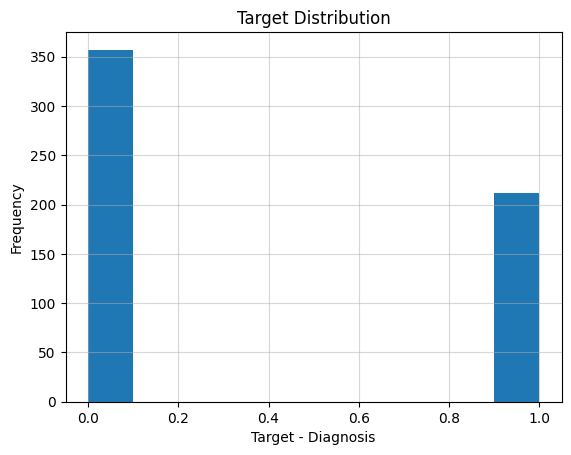

In [22]:
plt.hist(y)
plt.xlabel("Target - Diagnosis")
plt.ylabel("Frequency")
plt.title("Target Distribution")
plt.grid(True, alpha = 0.5)
plt.show()

In [23]:
counts = y.value_counts().sort_index()

malignant = counts[1]
benign = counts[0]

total = malignant + benign

print(f"The number of malignant cases is: {(malignant)}")
print(f"The number of benign cases is: {benign}")
print()
print(f"The percentage of benign cases is: {round((benign *100/total),3) }%")
print(f"The percentage of malignant cases is: {round((malignant *100/total),3) }%")
print()


The number of malignant cases is: 212
The number of benign cases is: 357

The percentage of benign cases is: 62.742%
The percentage of malignant cases is: 37.258%



Due to the uneven distribution in the target, stratified sampling will be needed to ensure that the training and test set have data that is representitive of the split between benign and malignant cases

In [24]:
#train/test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")




print("y distribution in original:", np.bincount(y))
print("y distribution in train:   ", np.bincount(y_train))
print("y distribution in test:    ", np.bincount(y_test))


X_train shape: (398, 30)
y_train shape: (398,)
X_test shape: (171, 30)
y_test shape: (171,)
y distribution in original: [357 212]
y distribution in train:    [250 148]
y distribution in test:     [107  64]


# Train/Test Split writeup

The dataset was divided into training and test sets with a 70:30 % split. Stratified sampling applied to preserve the original distribution of benign and malignant cases. The original dataset contained 62.74% benign cases and 37.26% malignant cases. Similar proportions were maintained in both training and test sets.



# Exploratory Data Analysis

In [25]:
X_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
78,20.18,23.97,143.70,1245.0,0.12860,0.34540,0.37540,0.16040,0.2906,0.08142,...,23.37,31.72,170.30,1623.0,0.1639,0.6164,0.7681,0.2508,0.5440,0.09964
330,16.03,15.51,105.80,793.2,0.09491,0.13710,0.12040,0.07041,0.1782,0.05976,...,18.76,21.98,124.30,1070.0,0.1435,0.4478,0.4956,0.1981,0.3019,0.09124
378,13.66,15.15,88.27,580.6,0.08268,0.07548,0.04249,0.02471,0.1792,0.05897,...,14.54,19.64,97.96,657.0,0.1275,0.3104,0.2569,0.1054,0.3387,0.09638
213,17.42,25.56,114.50,948.0,0.10060,0.11460,0.16820,0.06597,0.1308,0.05866,...,18.07,28.07,120.40,1021.0,0.1243,0.1793,0.2803,0.1099,0.1603,0.06818
89,14.64,15.24,95.77,651.9,0.11320,0.13390,0.09966,0.07064,0.2116,0.06346,...,16.34,18.24,109.40,803.6,0.1277,0.3089,0.2604,0.1397,0.3151,0.08473


In [26]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 398 entries, 78 to 129
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              398 non-null    float64
 1   mean texture             398 non-null    float64
 2   mean perimeter           398 non-null    float64
 3   mean area                398 non-null    float64
 4   mean smoothness          398 non-null    float64
 5   mean compactness         398 non-null    float64
 6   mean concavity           398 non-null    float64
 7   mean concave points      398 non-null    float64
 8   mean symmetry            398 non-null    float64
 9   mean fractal dimension   398 non-null    float64
 10  radius error             398 non-null    float64
 11  texture error            398 non-null    float64
 12  perimeter error          398 non-null    float64
 13  area error               398 non-null    float64
 14  smoothness error         398 n

In [27]:
y_train.head()

,target
78,1
330,1
378,0
213,1
89,0


**Correlation Analysis**

In [28]:
corr_matrix = X_train.corr()


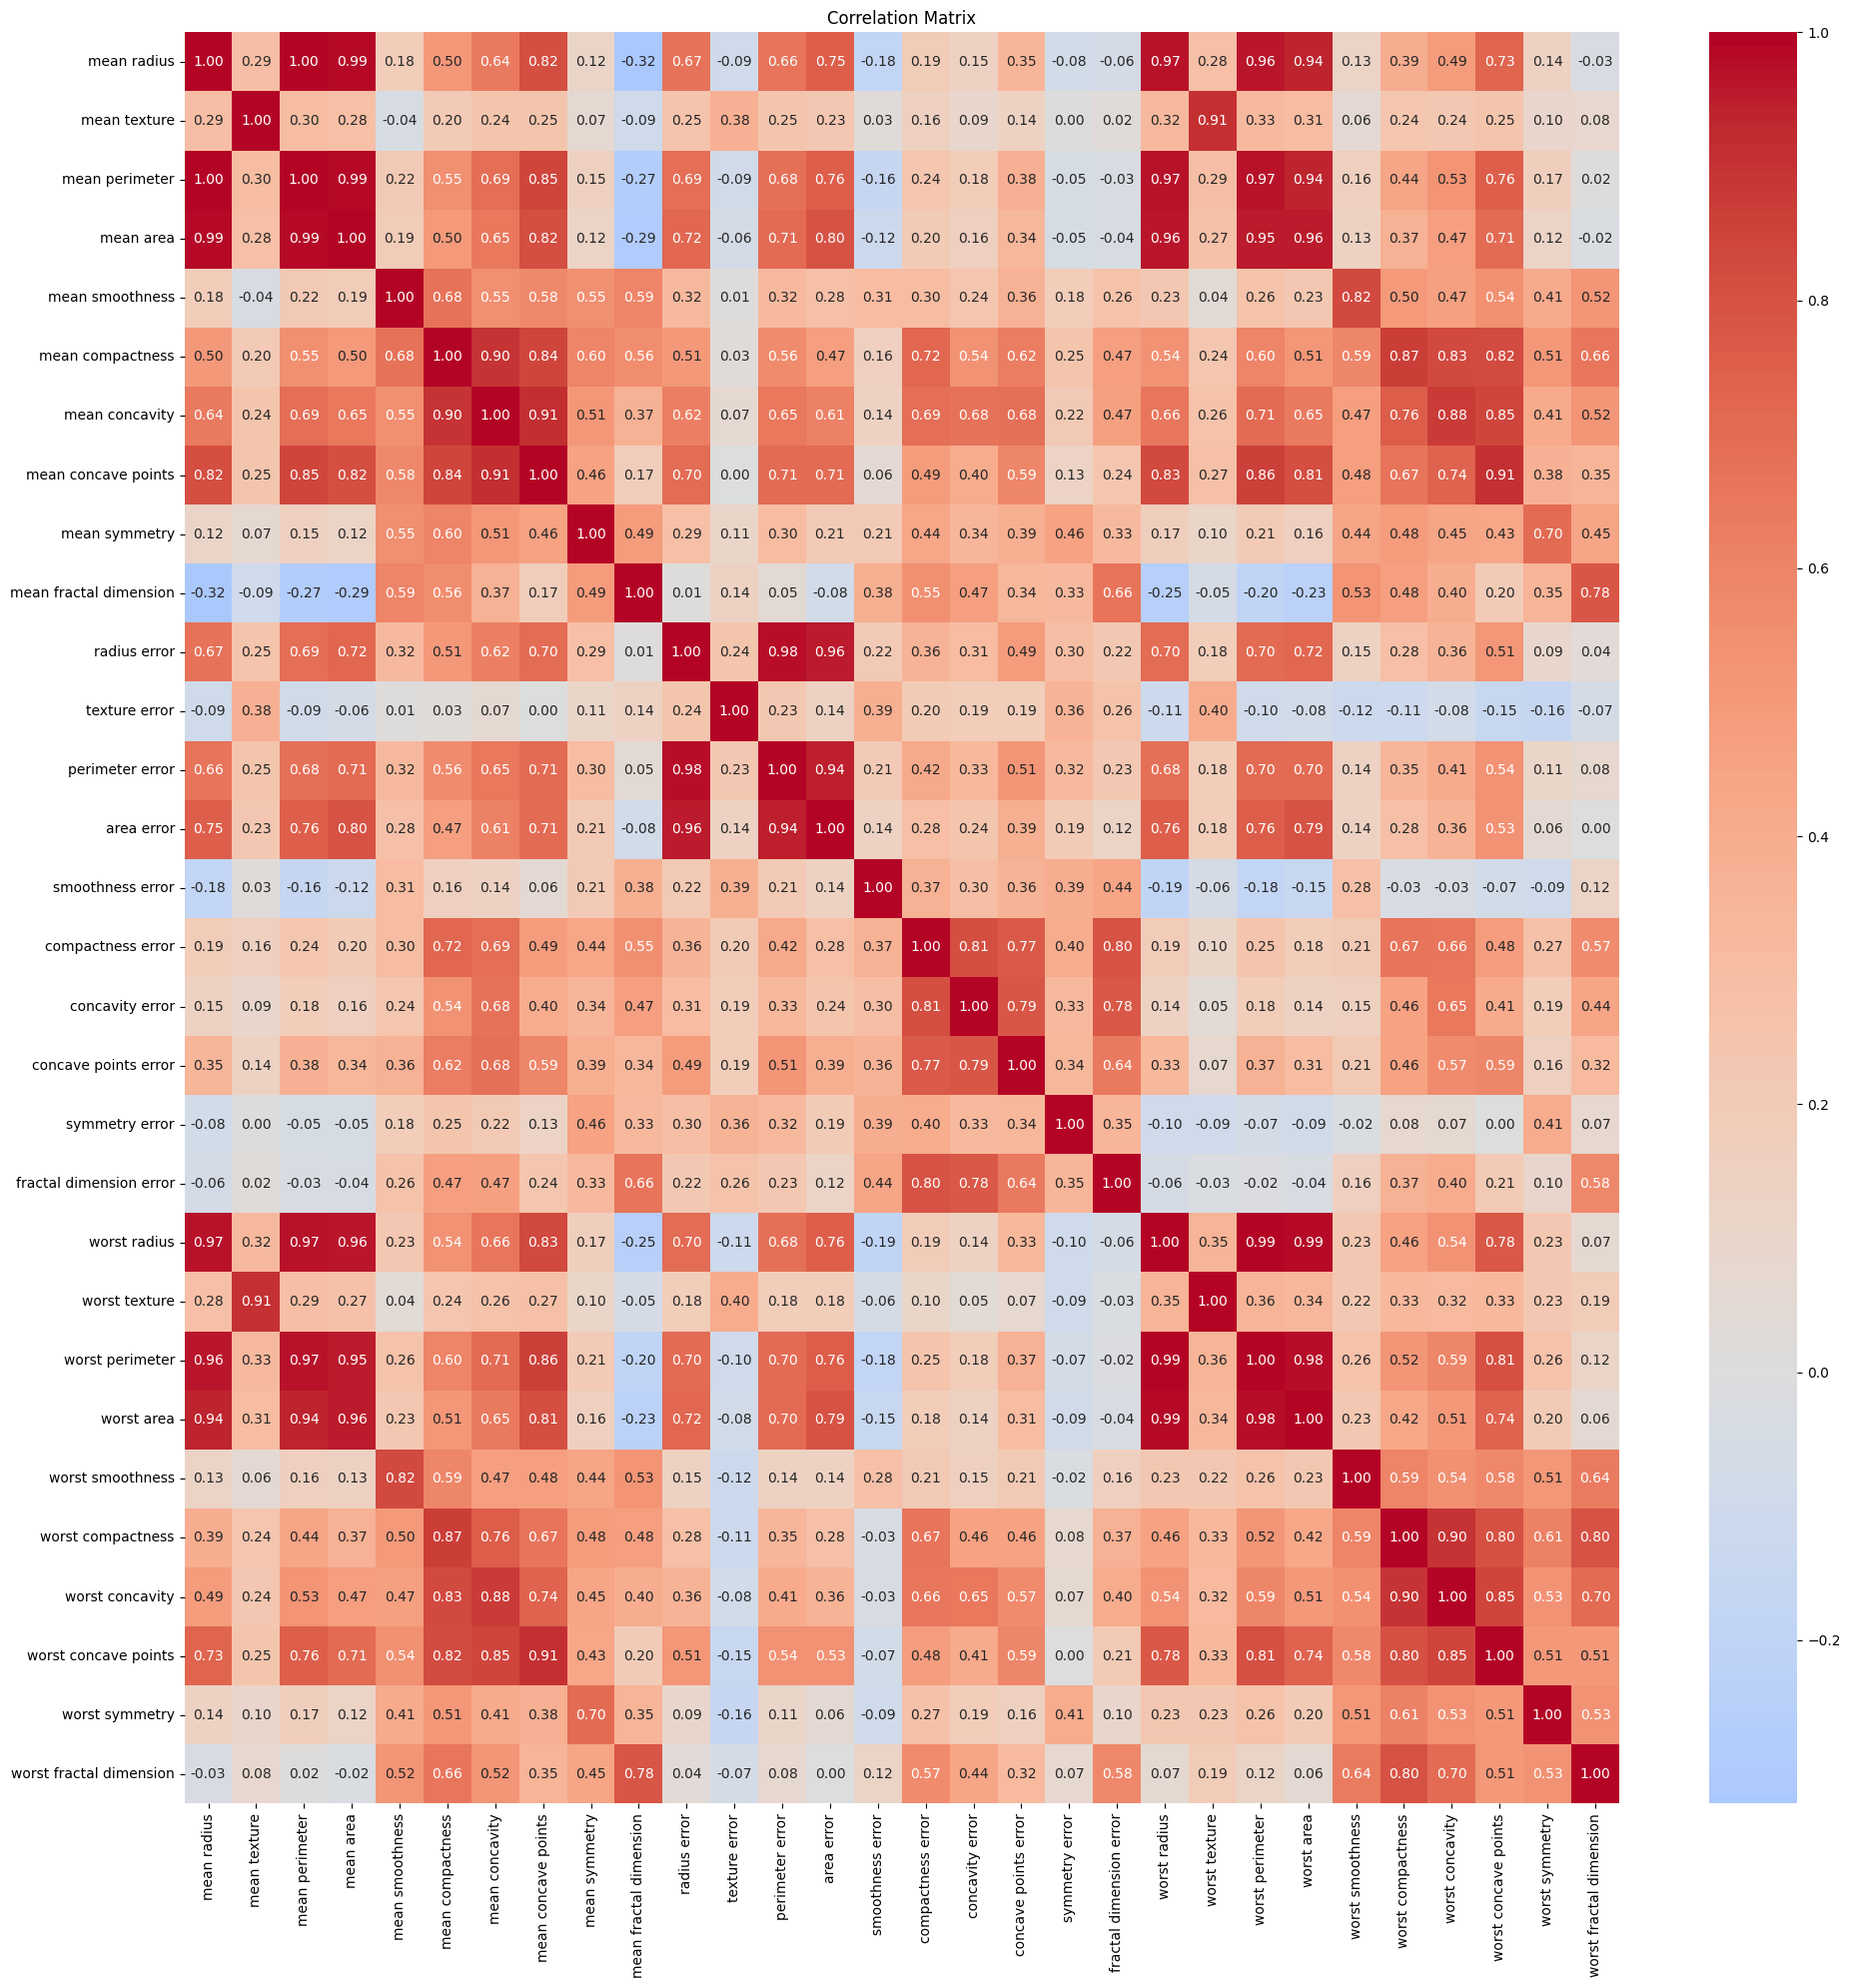

In [29]:
plt.figure(figsize=(20, 20))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            center = 0
            )


plt.xticks(rotation = 90, fontsize = 10)
plt.yticks(rotation = 0, fontsize = 10)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [30]:
train_df = X_train.copy()
train_df["target"] = y_train
train_df.drop("target", axis = 1, inplace = True)
train_corr = train_df.corr()

target_corr = train_df.corrwith(y_train).sort_values(ascending = False)


In [31]:
target_corr

,0
worst perimeter,0.781133
worst concave points,0.779404
worst radius,0.774868
mean concave points,0.767937
worst area,0.737012
mean perimeter,0.735620
mean radius,0.722837
mean area,0.703440
mean concavity,0.664965
worst concavity,0.625757


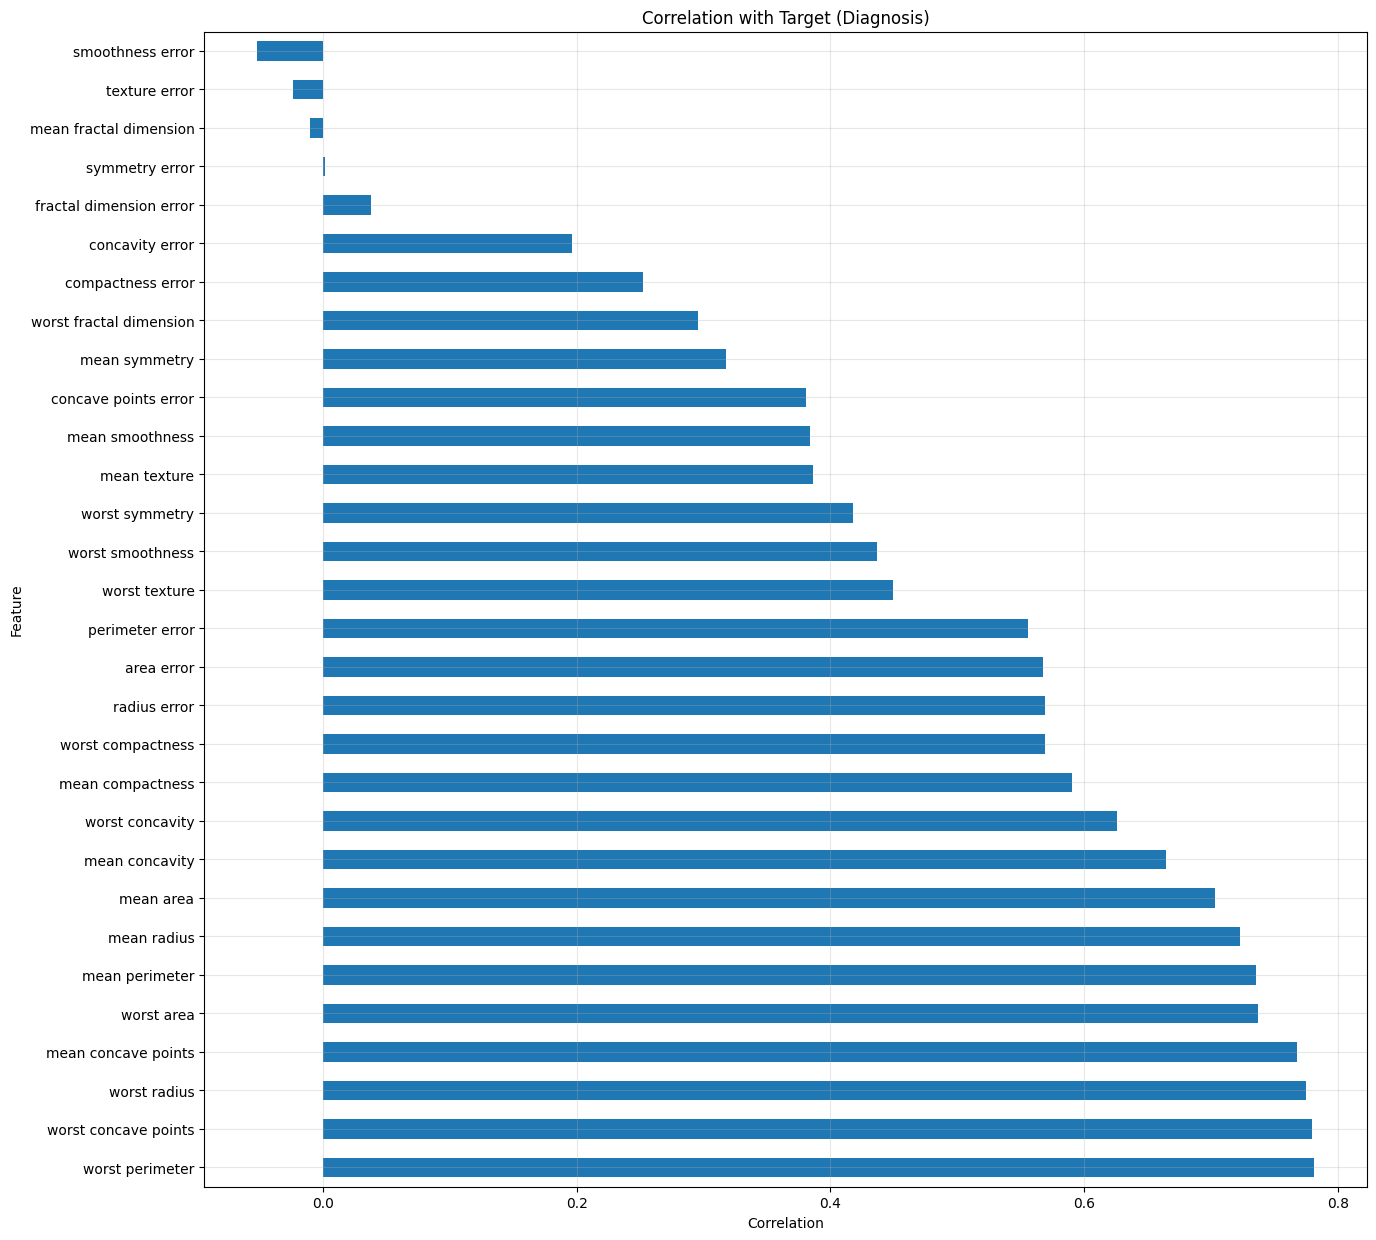

In [32]:
target_corr.plot(kind = "barh", figsize = (15,15))

plt.title("Correlation with Target (Diagnosis)")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.grid(True, alpha = 0.3)
plt.show()

In [33]:
def get_strong_feature_correlations(data_frame, correlation_threshold):

  """
  Finding strongly correlated features within a dataframe
  Fo

  """

  if correlation_threshold < 0 or correlation_threshold > 1:
    raise ValueError("Threshold must be between 0 and 1")


  final_dictionary = {}

  corr_matrix = data_frame.corr()

  for i in corr_matrix:


    feature_corr = corr_matrix.loc[i].drop(i)

    strong_features = feature_corr.abs() >= correlation_threshold

    strong_corr = feature_corr[strong_features]
    strong_sorted = strong_corr.abs().sort_values(ascending = False).index

    if not strong_sorted.empty:
      final_dictionary[i] = feature_corr[strong_sorted]




  return final_dictionary




strong_corrs = get_strong_feature_correlations(X_train, correlation_threshold = 0.65)

In [34]:
strong_corrs

{'mean radius': mean perimeter          0.997743
 mean area               0.988068
 worst radius            0.968609
 worst perimeter         0.962247
 worst area              0.942030
 mean concave points     0.815090
 area error              0.748016
 worst concave points    0.727245
 radius error            0.672830
 perimeter error         0.664796
 Name: mean radius, dtype: float64,
 'mean texture': worst texture    0.910633
 Name: mean texture, dtype: float64,
 'mean perimeter': mean radius             0.997743
 mean area               0.986890
 worst radius            0.969029
 worst perimeter         0.968457
 worst area              0.942474
 mean concave points     0.845341
 area error              0.757233
 worst concave points    0.755873
 radius error            0.686410
 mean concavity          0.686151
 perimeter error         0.684646
 Name: mean perimeter, dtype: float64,
 'mean area': mean radius             0.988068
 mean perimeter          0.986890
 worst radius    

**Feature Distributions**

In [35]:
train_df.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='object')

In [36]:
full_train = pd.concat([X_train, y_train], axis=1)

full_train.columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension',
       'target'],
      dtype='object')

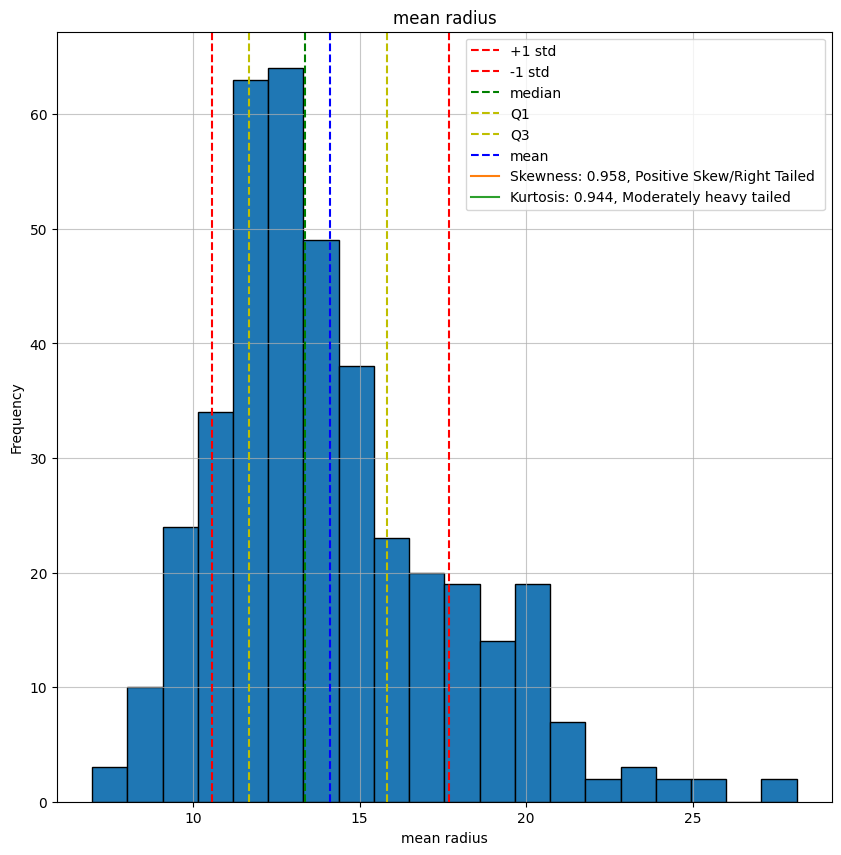

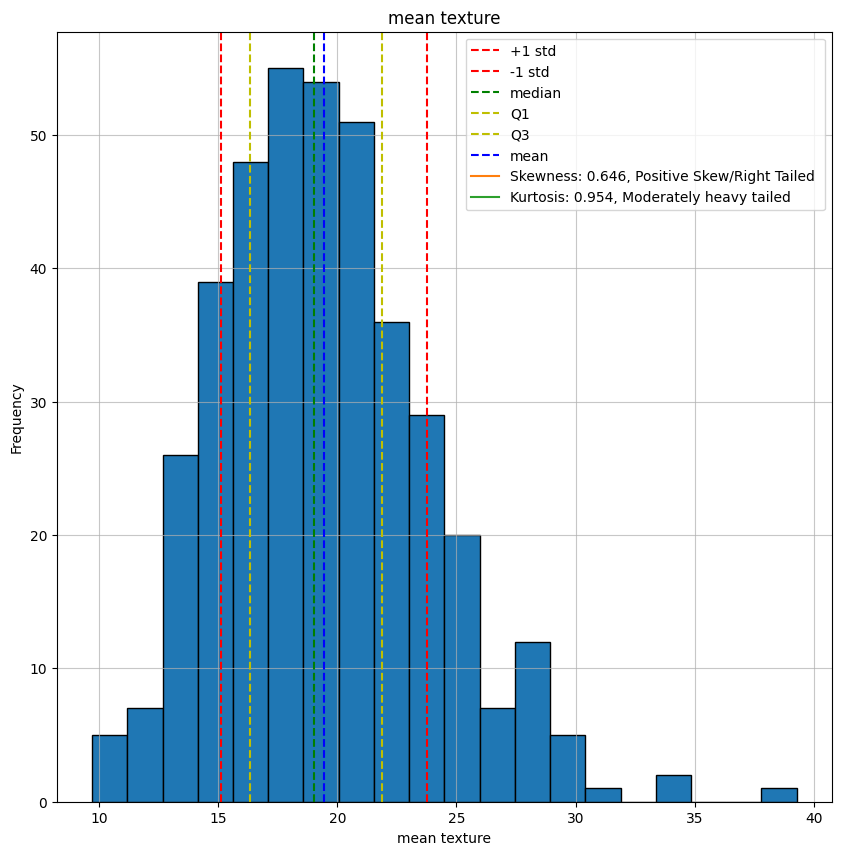

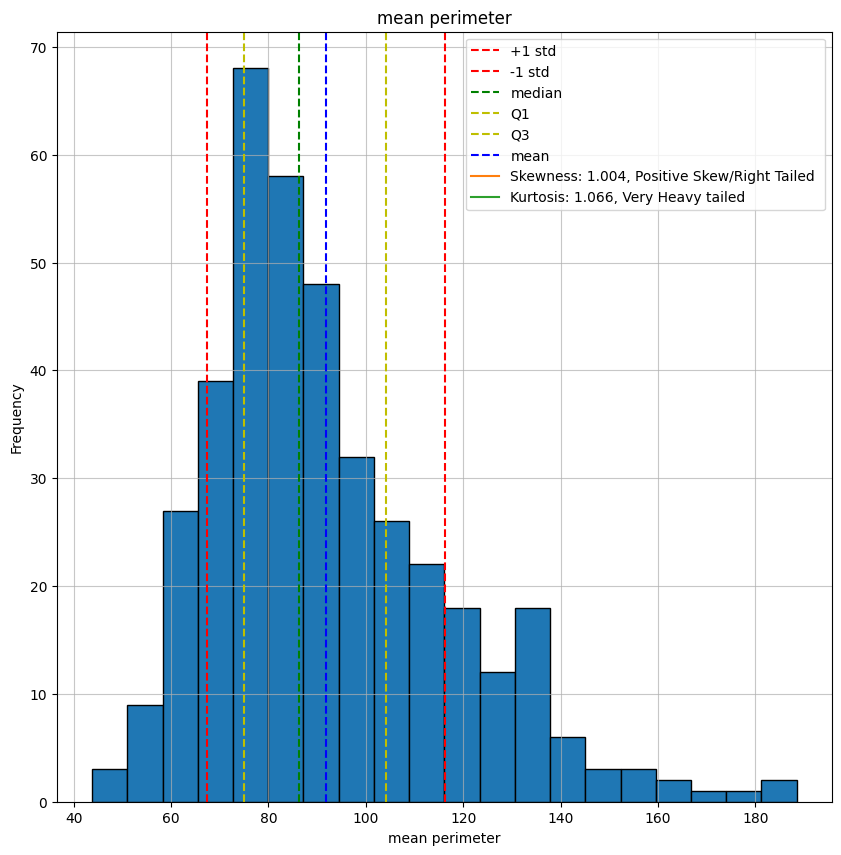

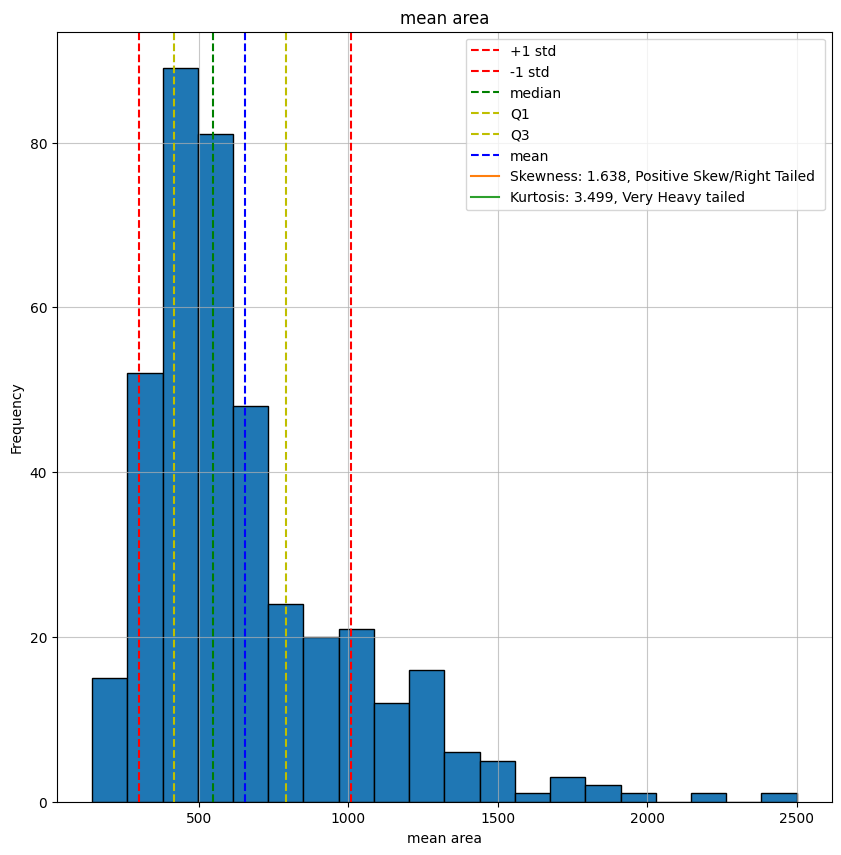

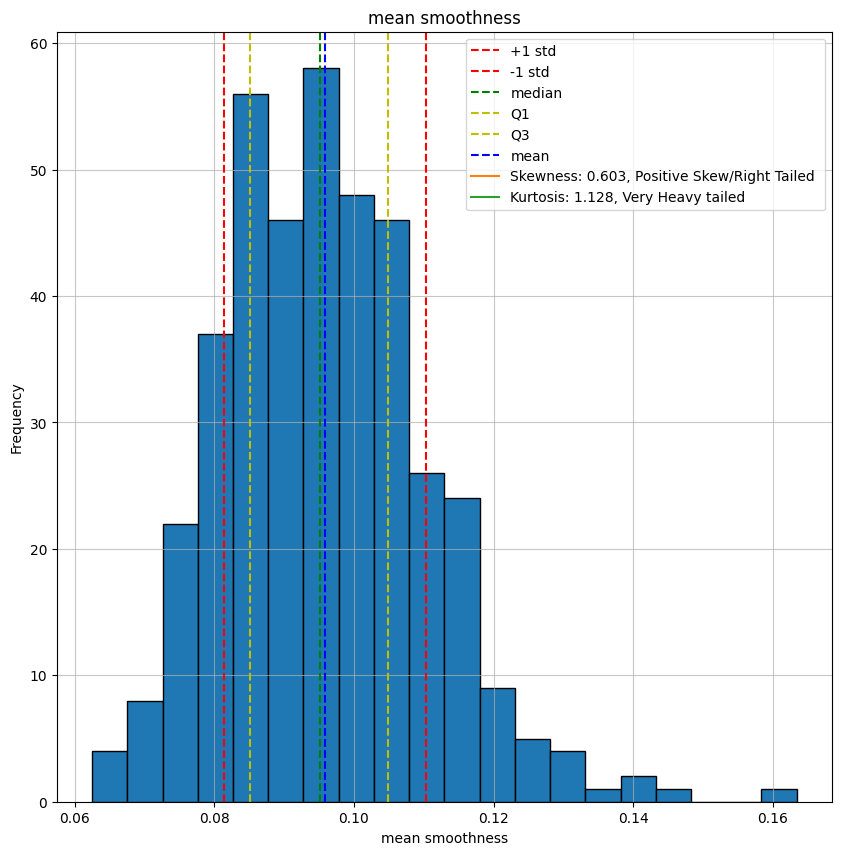

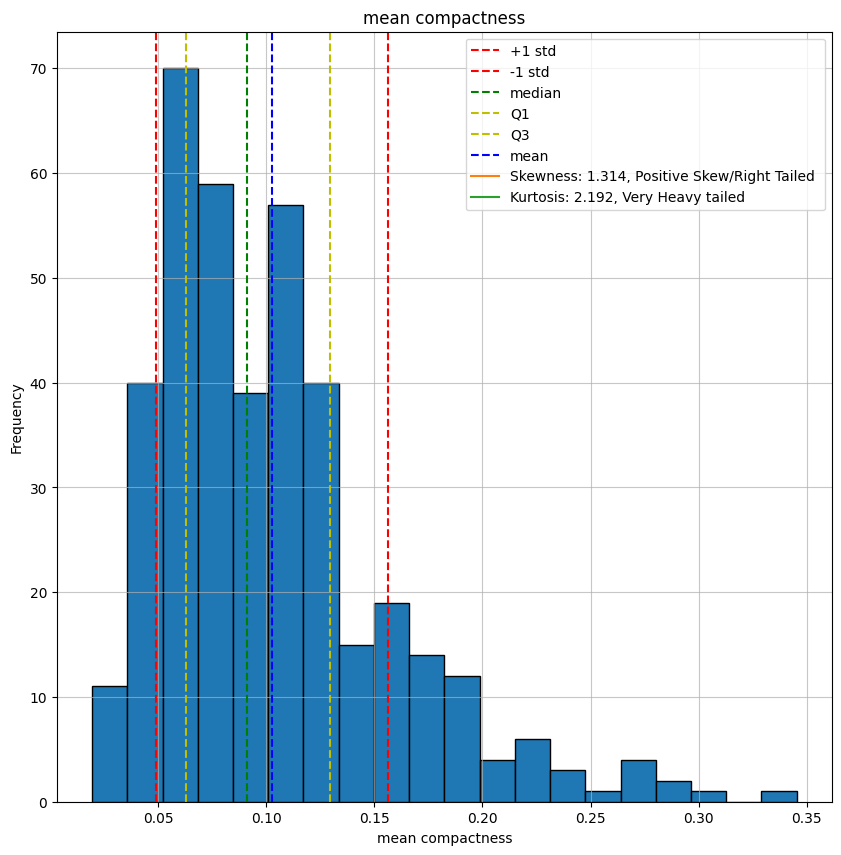

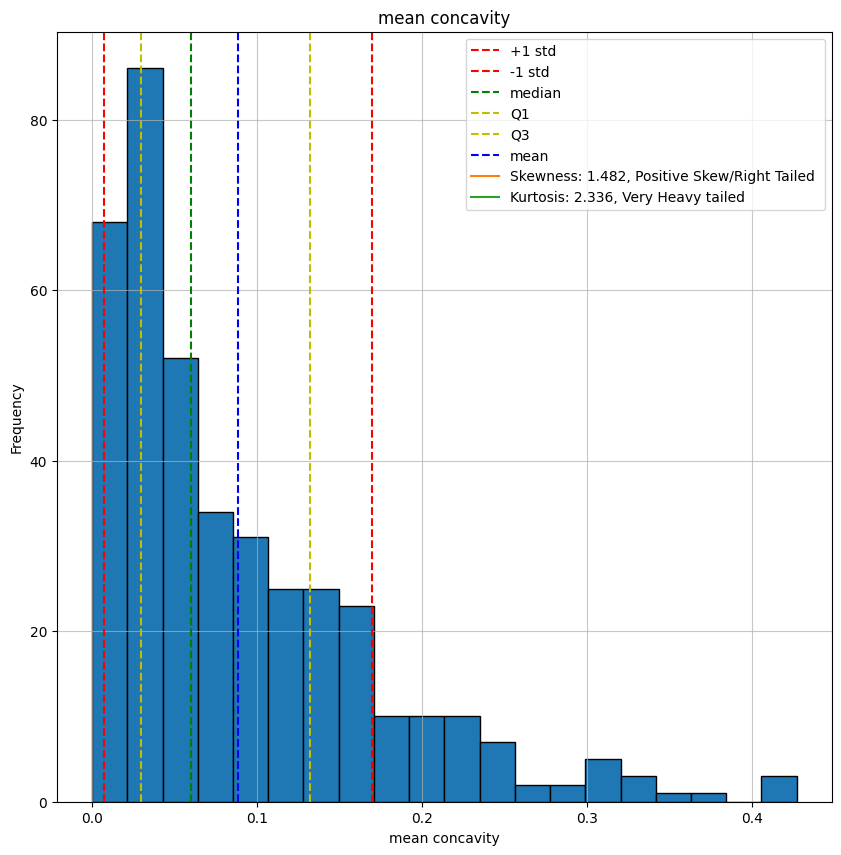

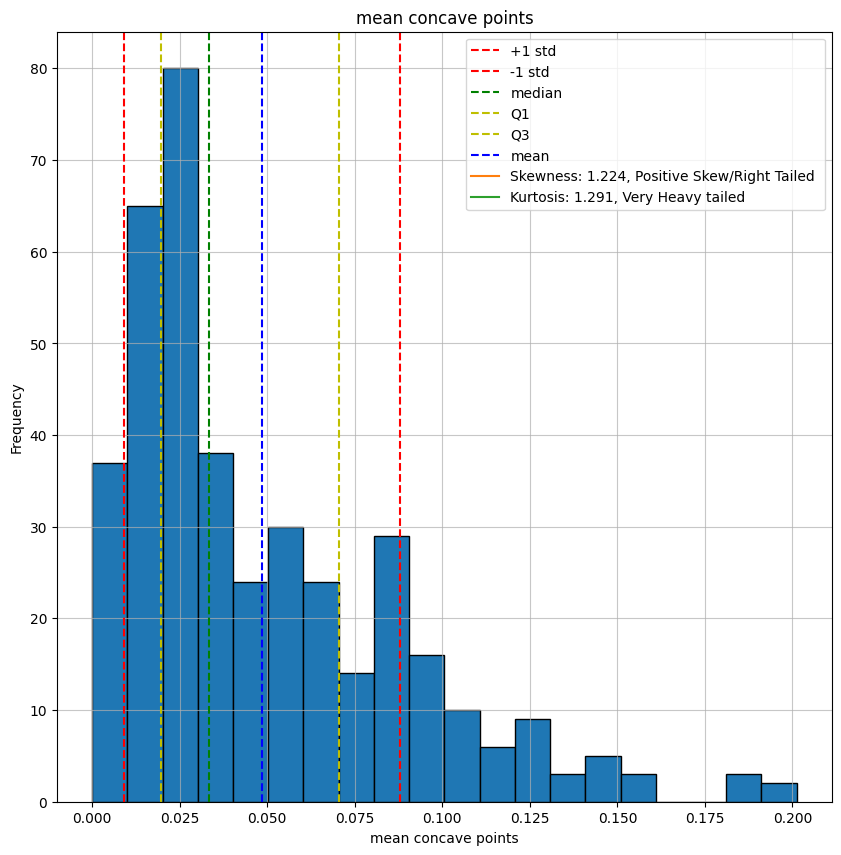

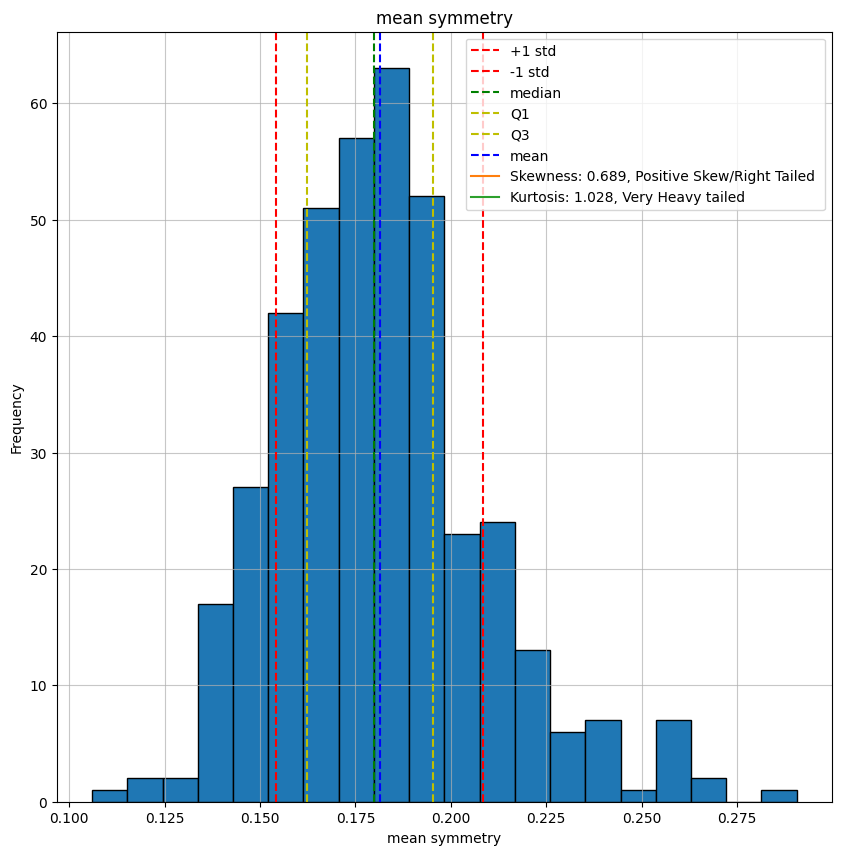

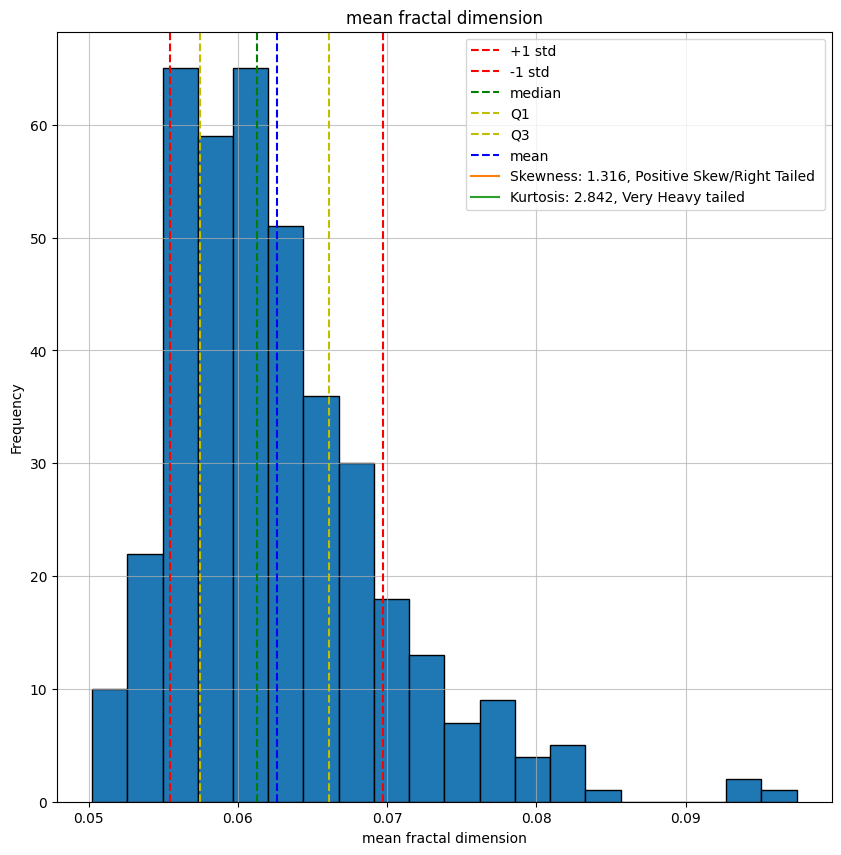

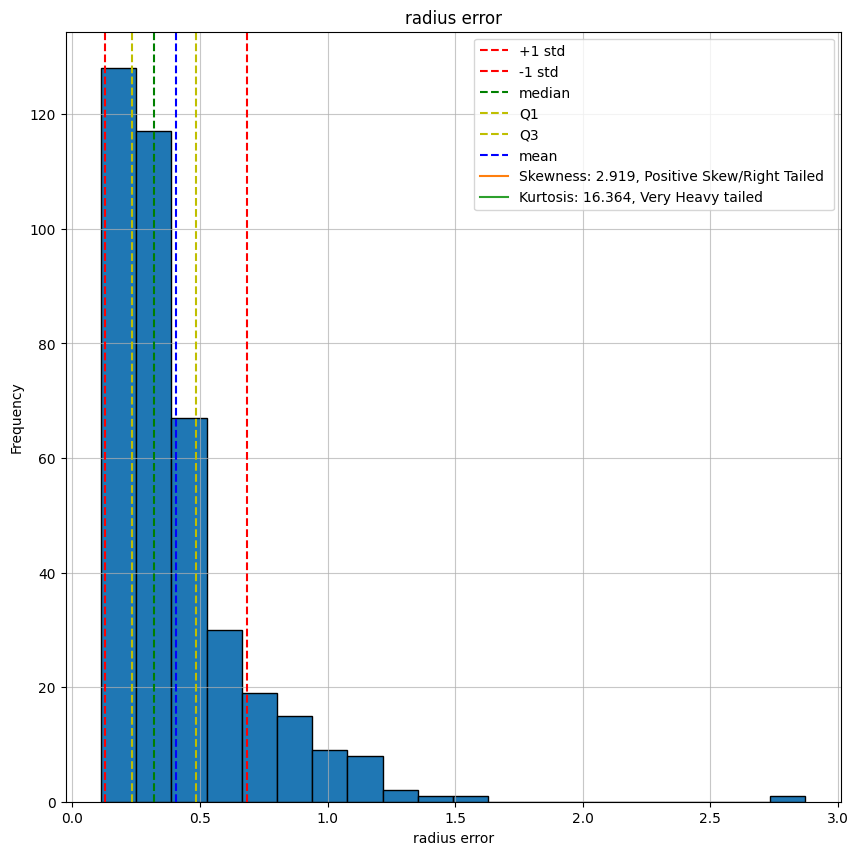

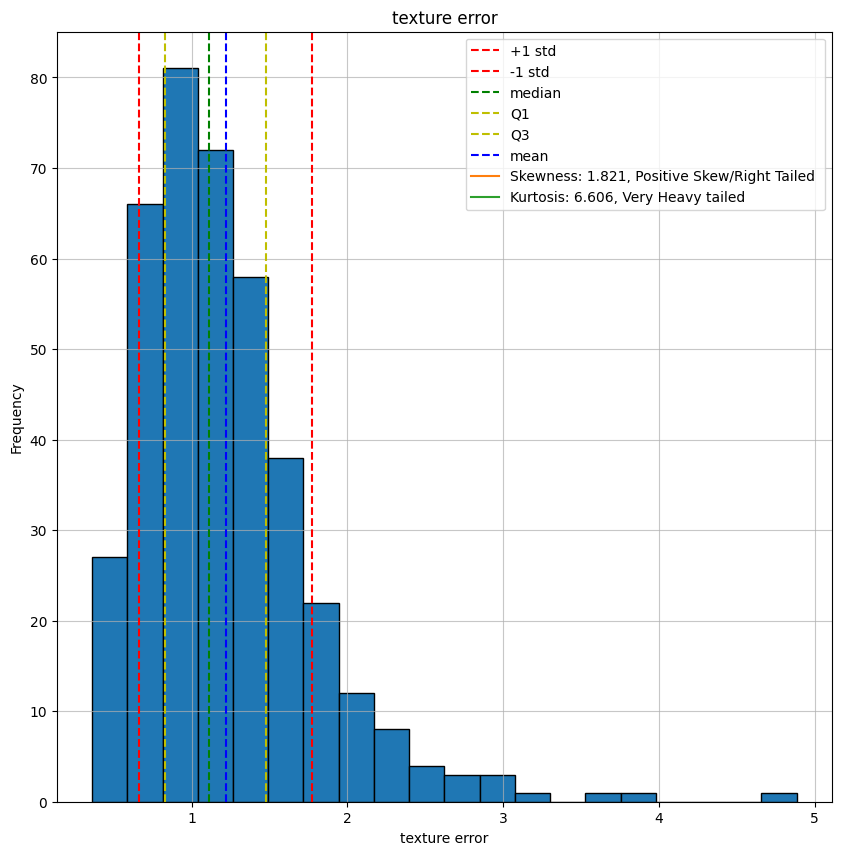

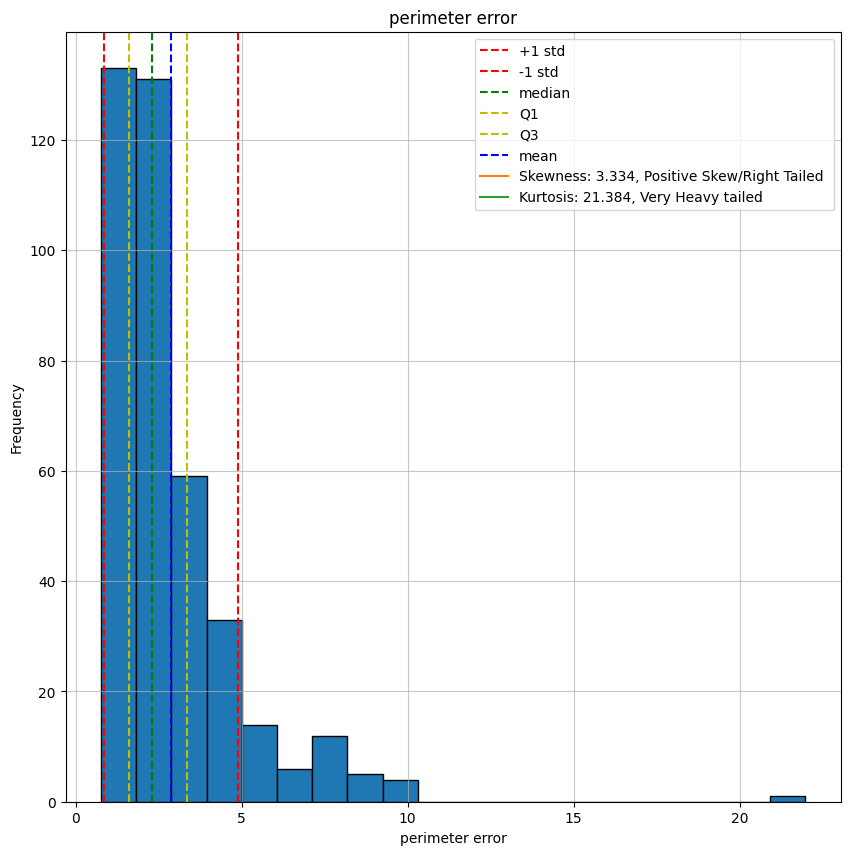

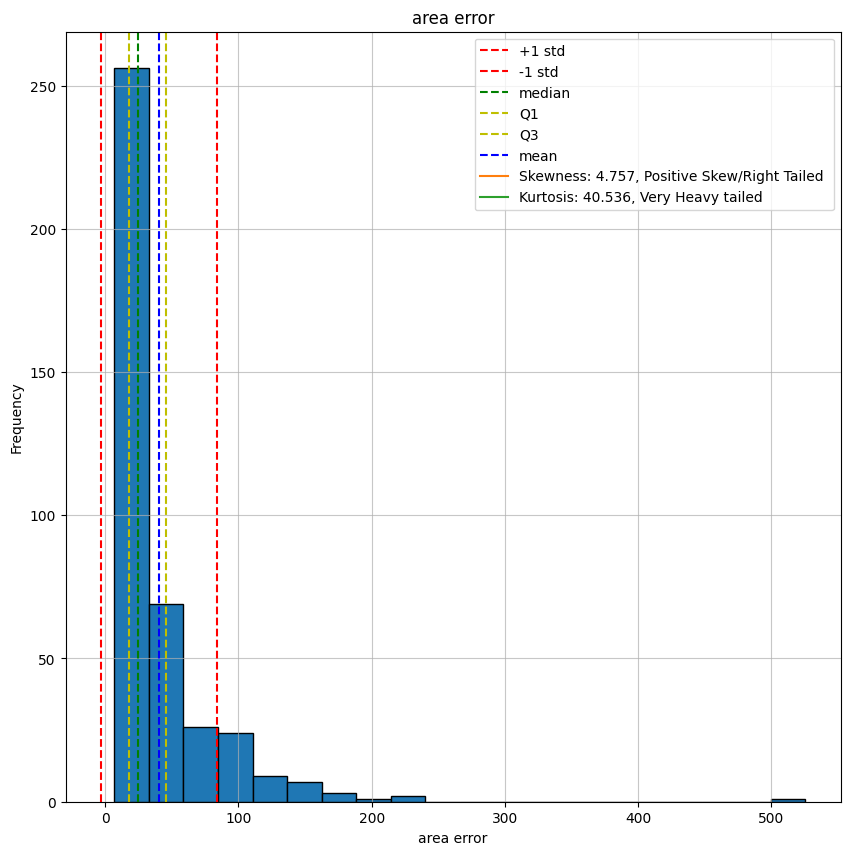

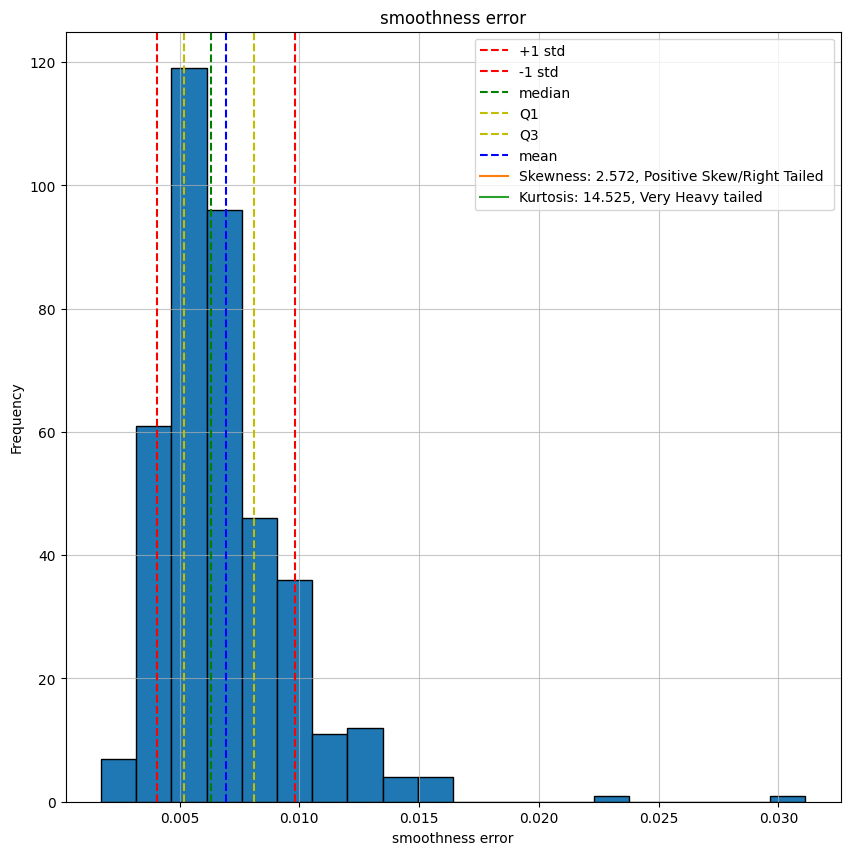

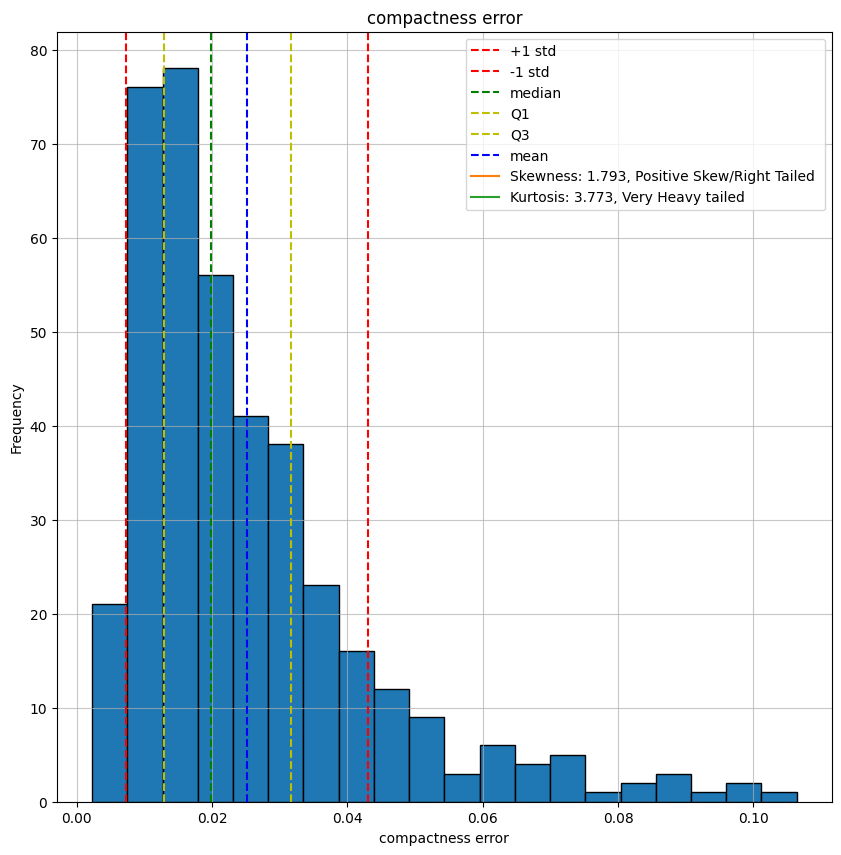

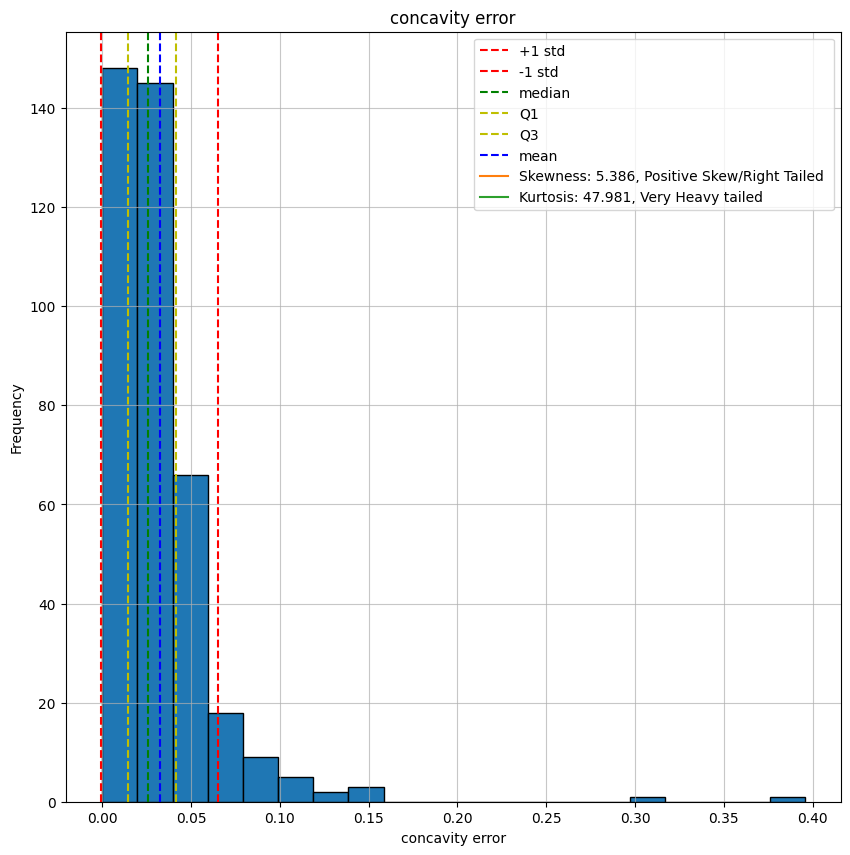

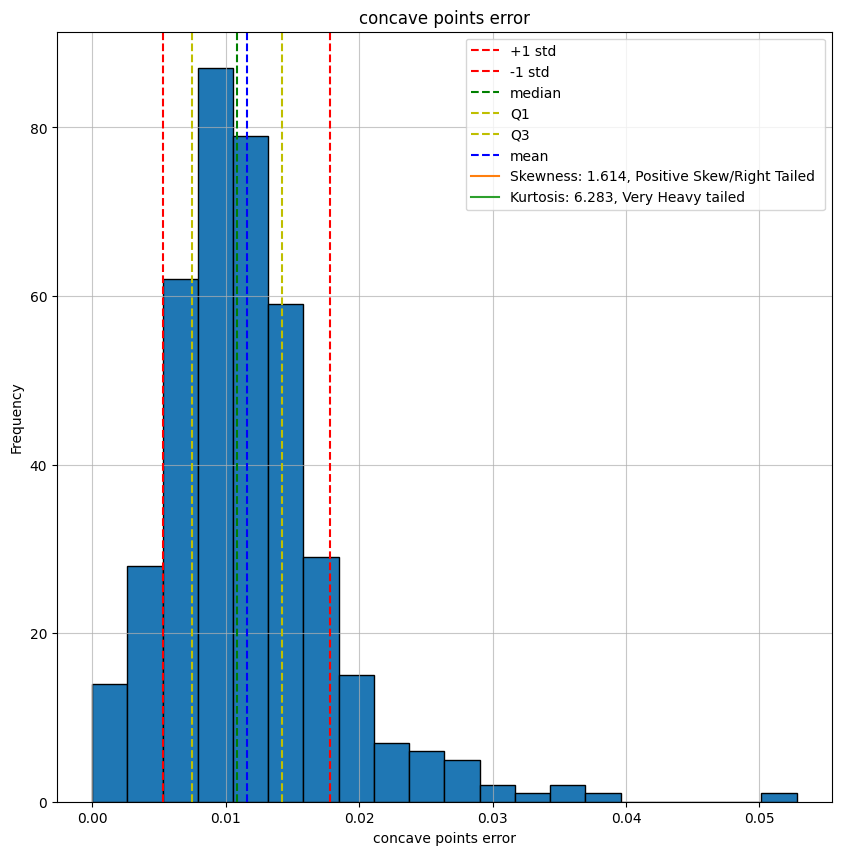

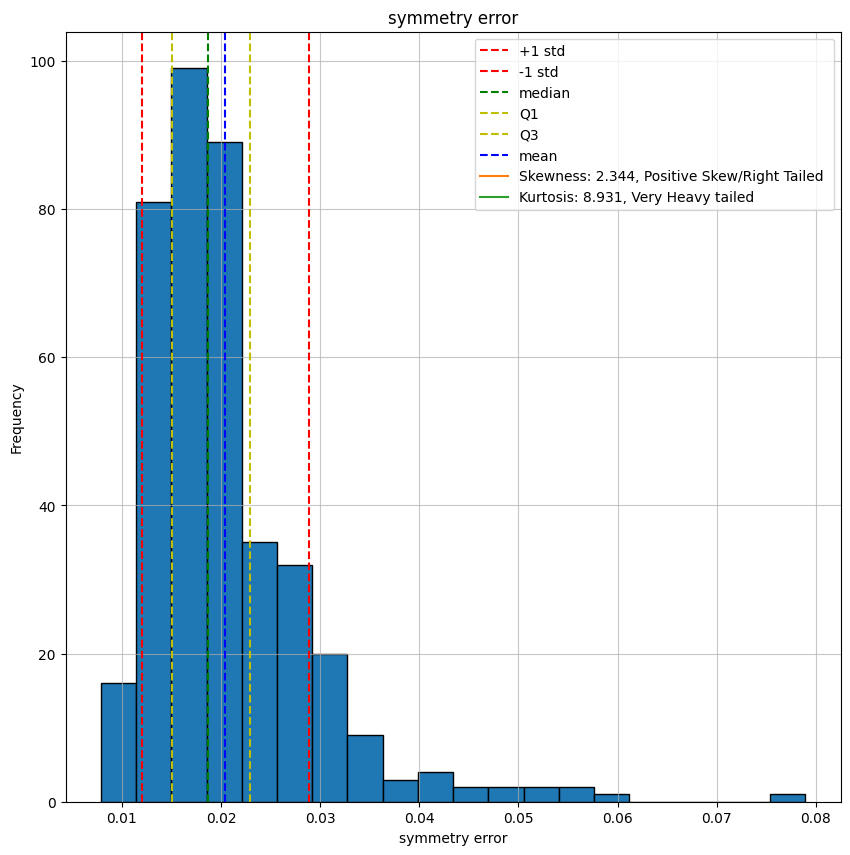

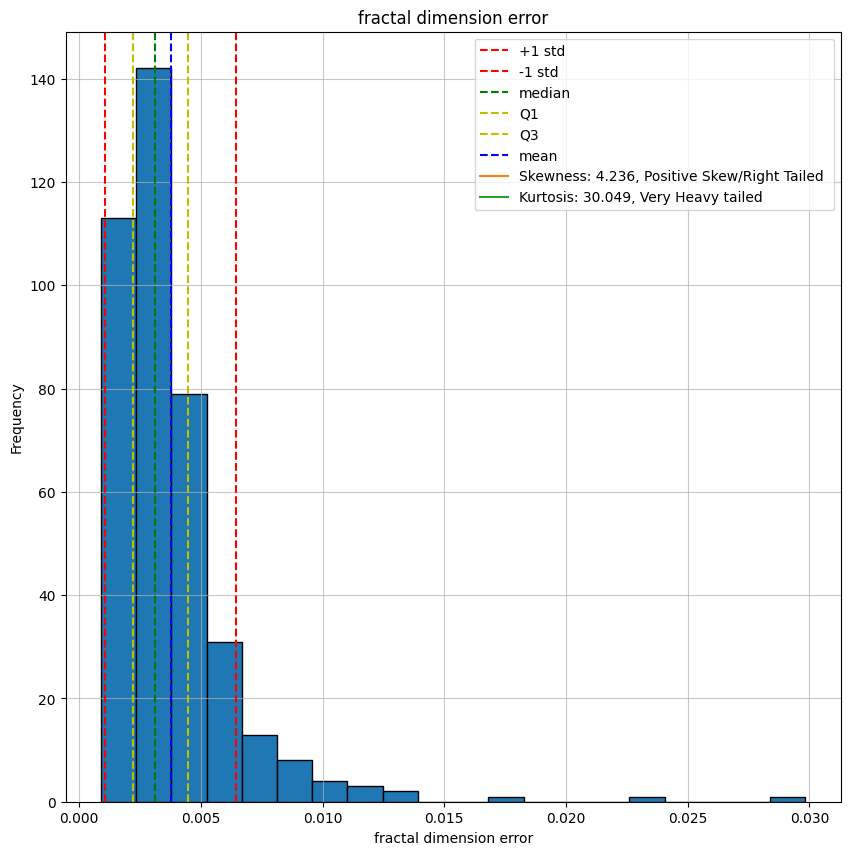

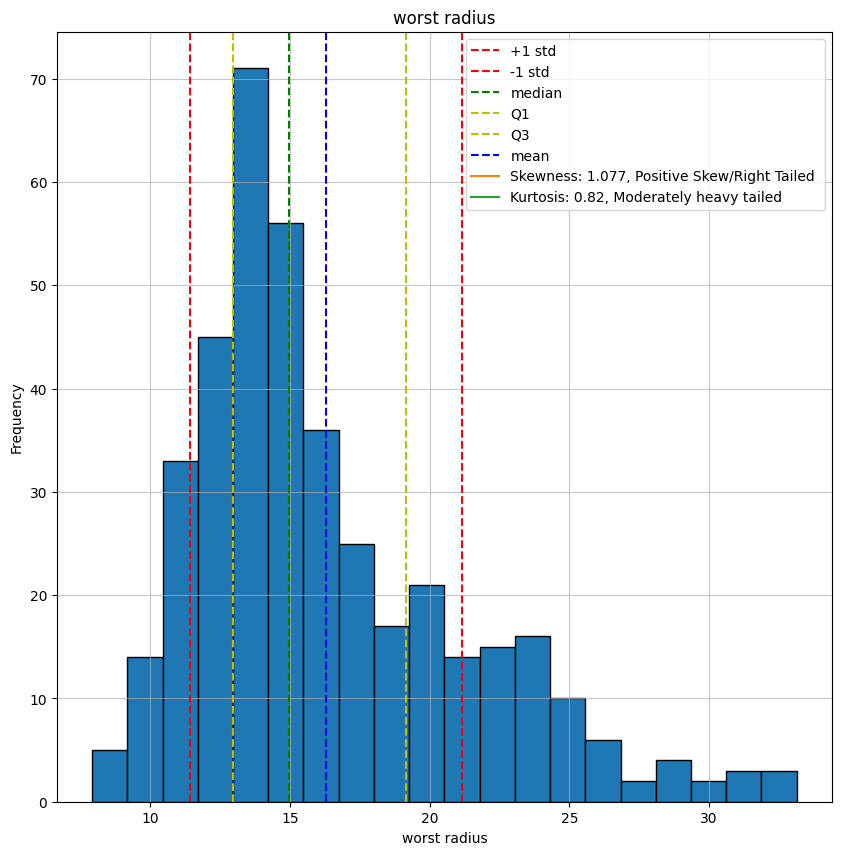

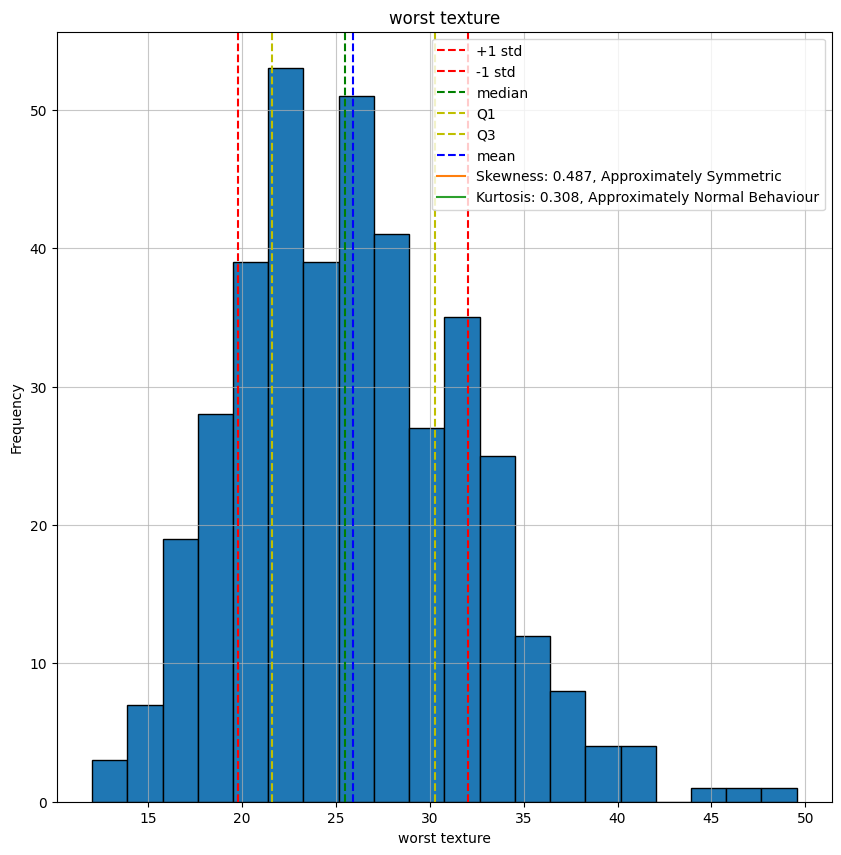

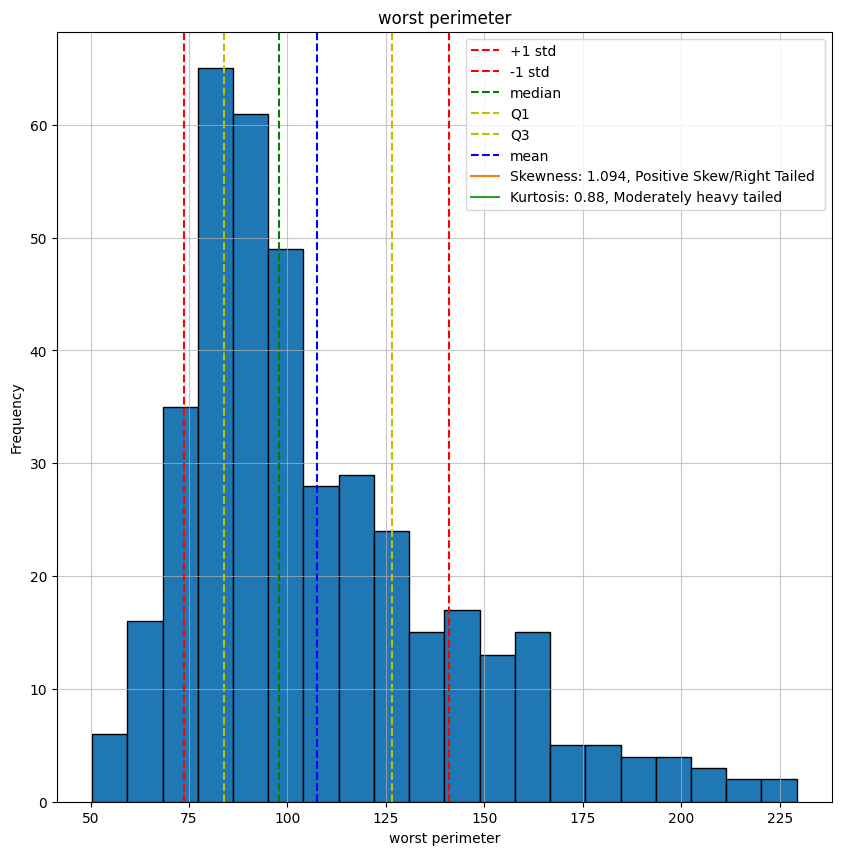

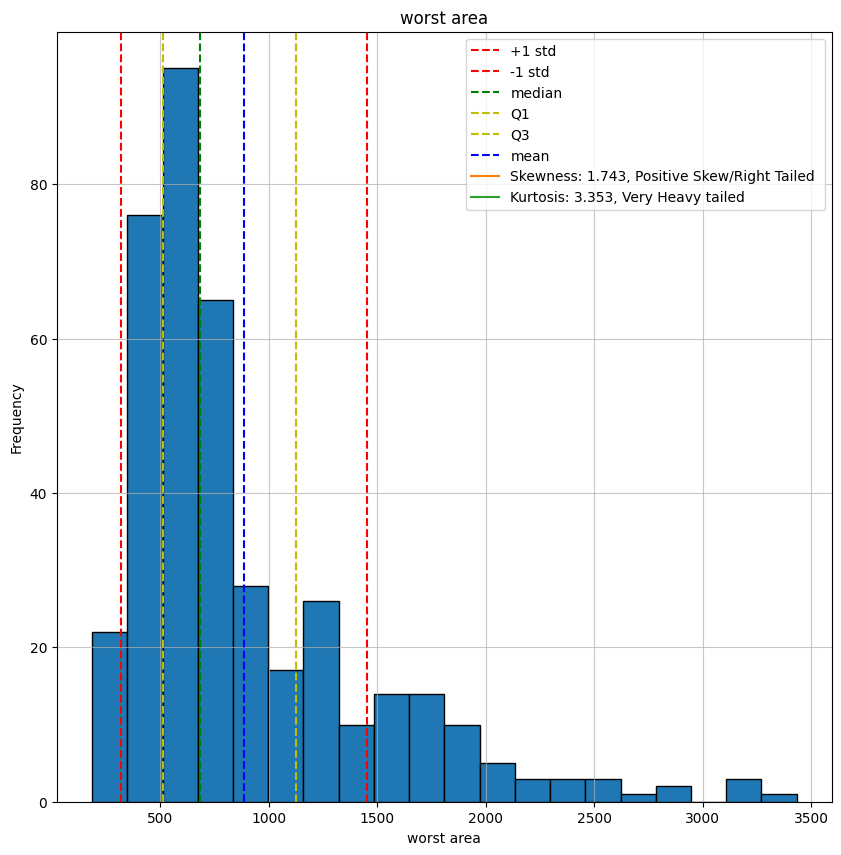

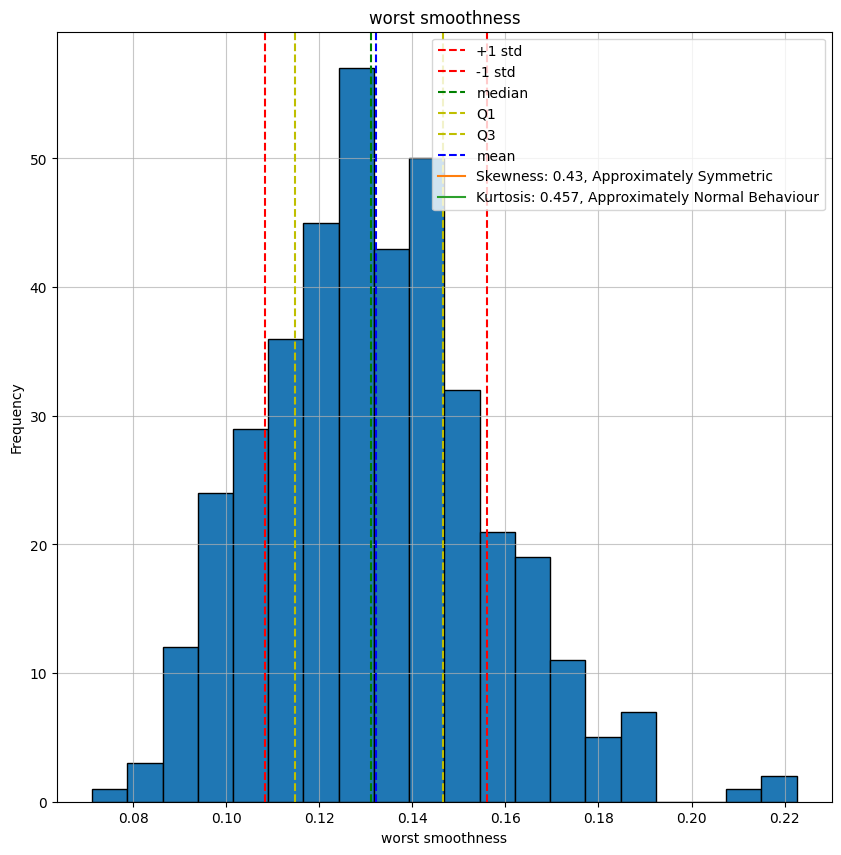

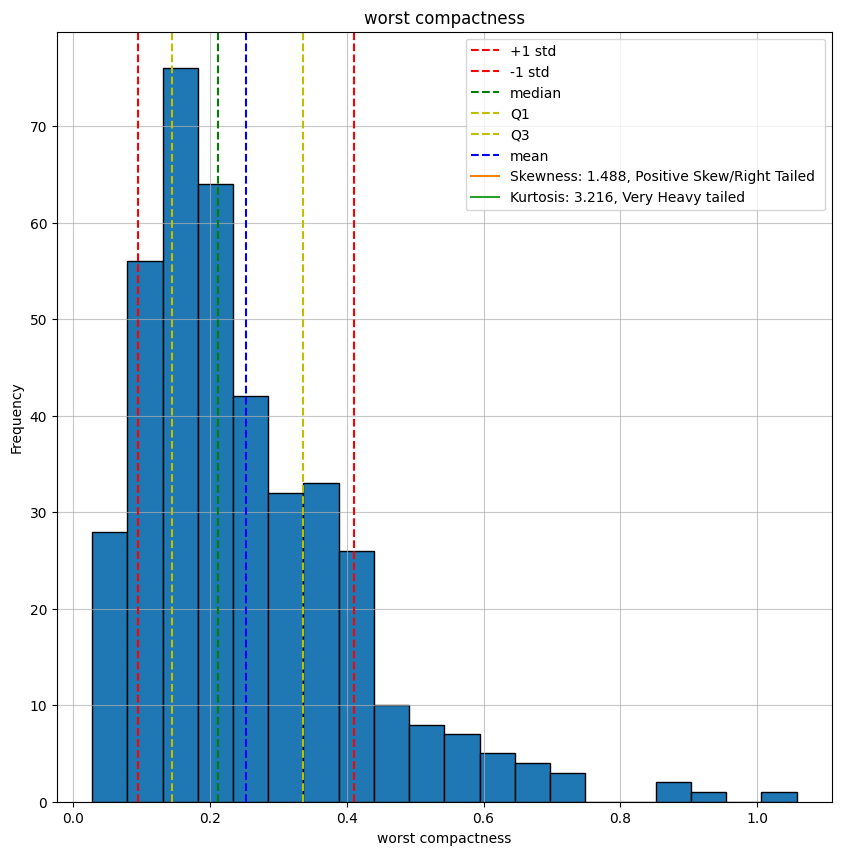

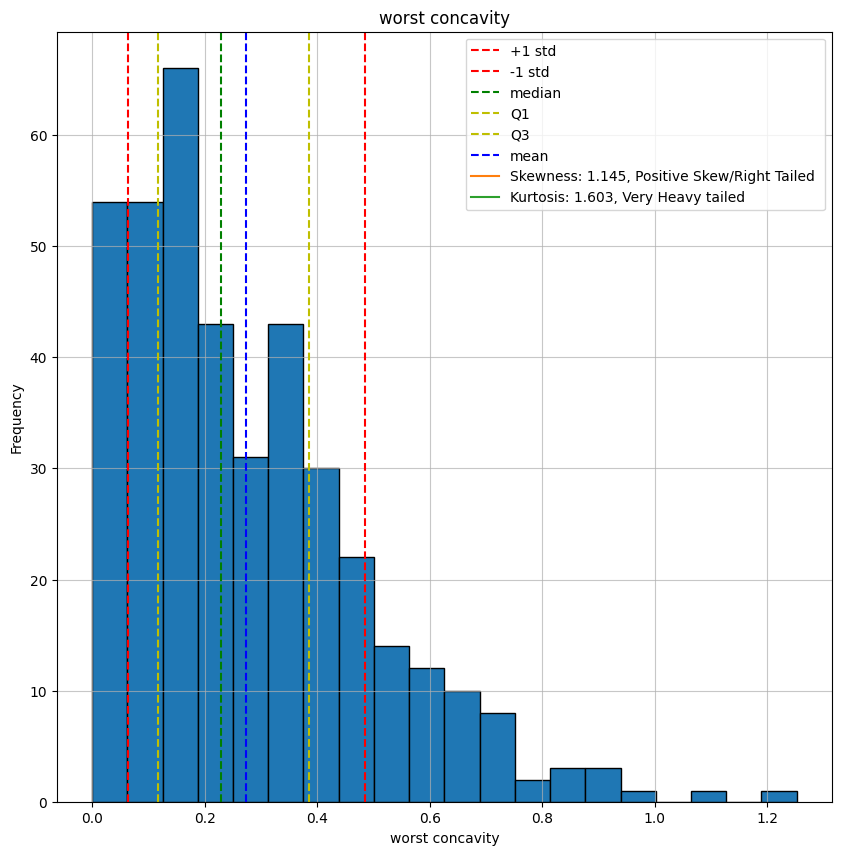

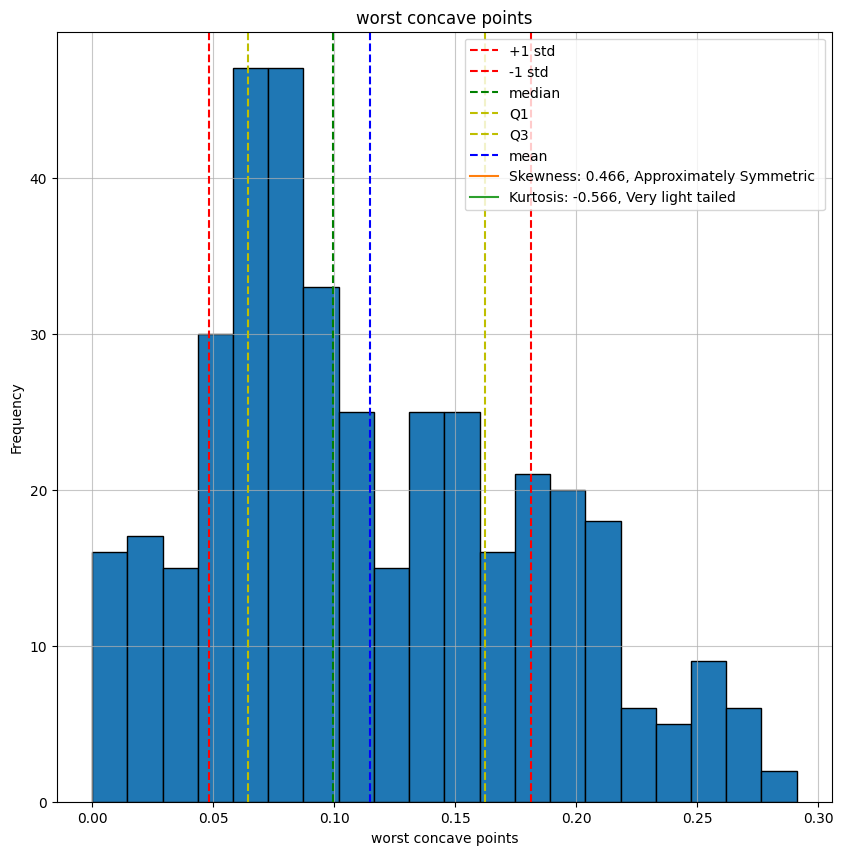

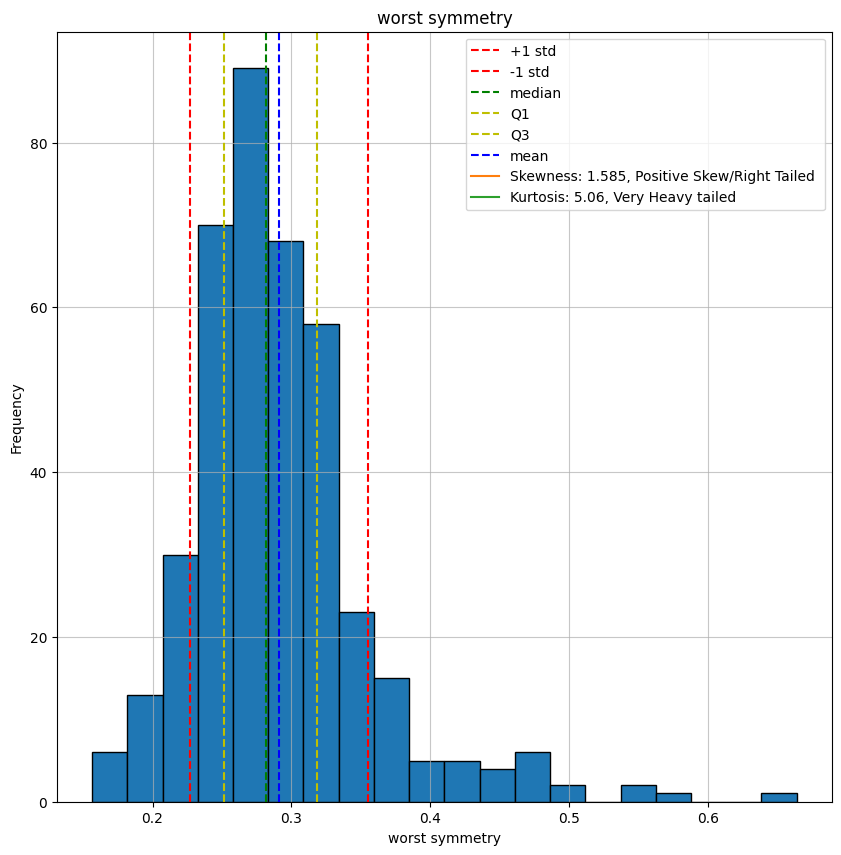

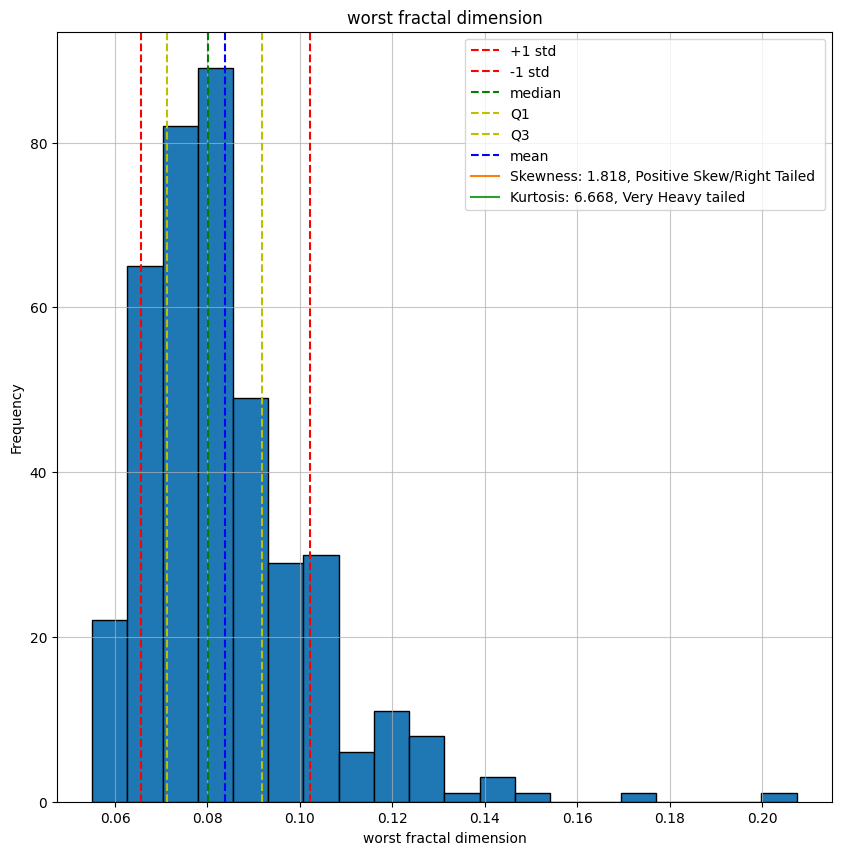

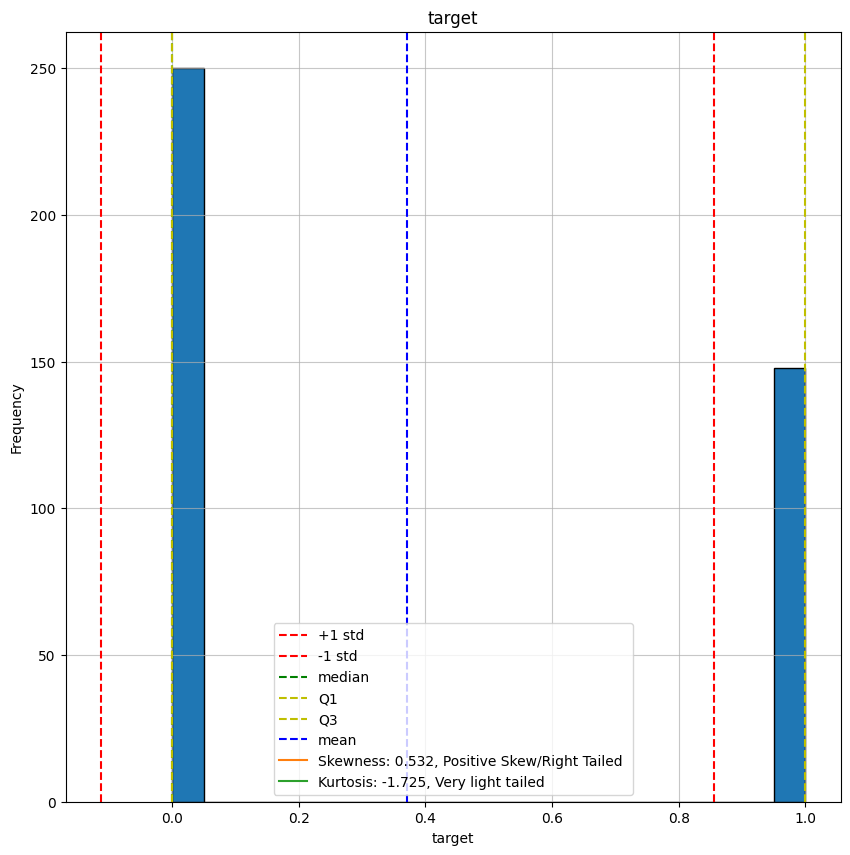

In [37]:
for i in full_train.columns:
  mean_i = full_train[i].mean()
  std_i = full_train[i].std()
  pos_std = mean_i + std_i
  neg_std = mean_i - std_i
  median_i = full_train[i].median()
  q1_i = full_train[i].quantile(0.25)
  q3_i = full_train[i].quantile(0.75)


  skew_i = full_train[i].skew()
  kurt_i = full_train[i].kurtosis()

  skew_txt = None
  if skew_i > 0.5:
    skew_txt = "Positive Skew/Right Tailed"
  elif skew_i < -0.5:
    skew_txt = "Negative Skew /Left Tailed"
  else:
    skew_txt = "Approximately Symmetric"


  kurtosis_txt = None

  if -0.5<= kurt_i <= 0.5:
    kurtosis_txt = "Approximately Normal Behaviour"
  elif 0.5 <kurt_i <= 1.0:
    kurtosis_txt = "Moderately heavy tailed"
  elif kurt_i > 1.0:
    kurtosis_txt = "Very Heavy tailed"
  else:
    kurtosis_txt = "Very light tailed"


  plt.figure(figsize=(10, 10))
  plt.hist(full_train[i], bins = 20, edgecolor = "black")
  plt.xlabel(f"{i}")
  plt.ylabel("Frequency")
  plt.title(i)

  plt.axvline(x=pos_std, color='r', linestyle='--', label = "+1 std")
  plt.axvline(x=neg_std, color='r', linestyle='--', label = "-1 std")
  plt.axvline(x=median_i, color='g', linestyle='--', label = "median")
  plt.axvline(x=q1_i, color='y', linestyle='--', label = "Q1")
  plt.axvline(x=q3_i, color='y', linestyle='--', label = "Q3")
  plt.axvline(x =mean_i, color = "b", linestyle = "--", label = "mean")

  plt.plot([],[], "", label= f"Skewness: {round(skew_i,3)}, {skew_txt} ")
  plt.plot([],[], "", label= f"Kurtosis: {round(kurt_i,3)}, {kurtosis_txt}")




  plt.grid(True, alpha = 0.7)
  plt.legend()
  plt.show()

Number of zeros in y_train (benign): 250
Number of ones in y_train (malignant): 148


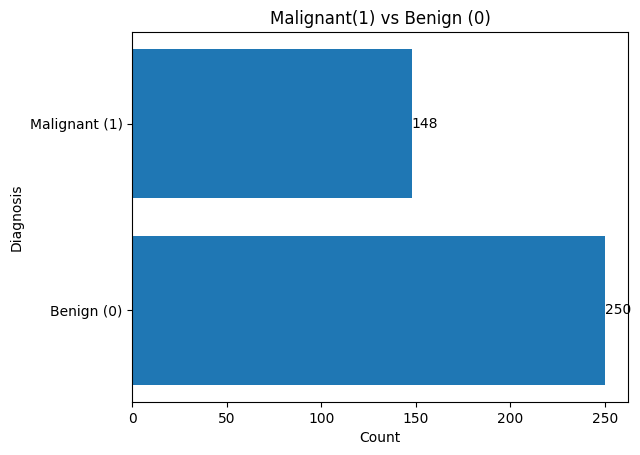

In [38]:
zero_count_benign = (y_train == 0).sum()
ones_count_malignant = (y_train == 1).sum()

print(f"Number of zeros in y_train (benign): {zero_count_benign}")
print(f"Number of ones in y_train (malignant): {ones_count_malignant}")


bars = plt.barh(
    ["Benign (0)", "Malignant (1)"],
    [zero_count_benign, ones_count_malignant]

)


plt.bar_label(bars)

plt.title('Malignant(1) vs Benign (0)')
plt.xlabel('Count')
plt.ylabel('Diagnosis')

plt.show()



In [39]:
full_train_copy = full_train.copy()

full_train_copy["Diagnosis"] = full_train_copy["target"].map({
    0:"Benign",
    1:"Malignant"
})

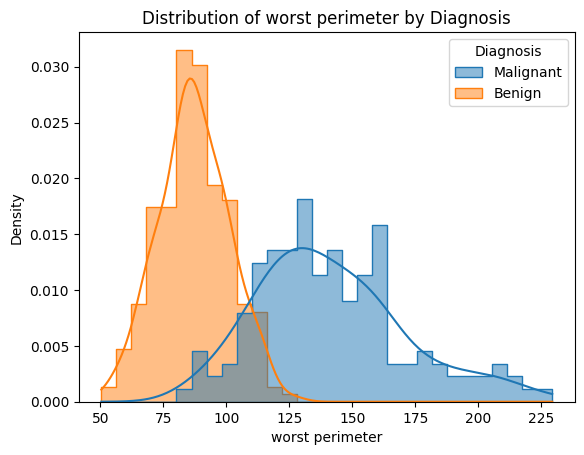

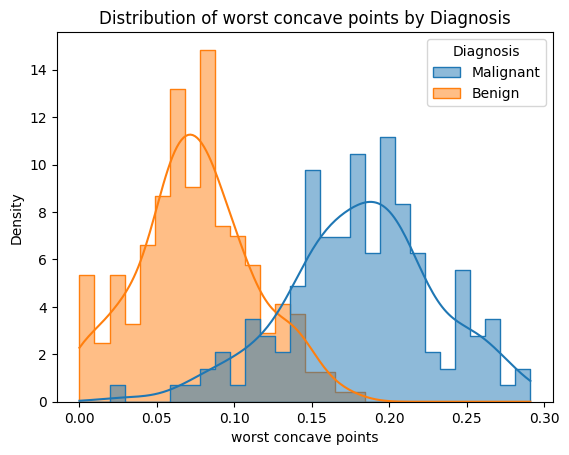

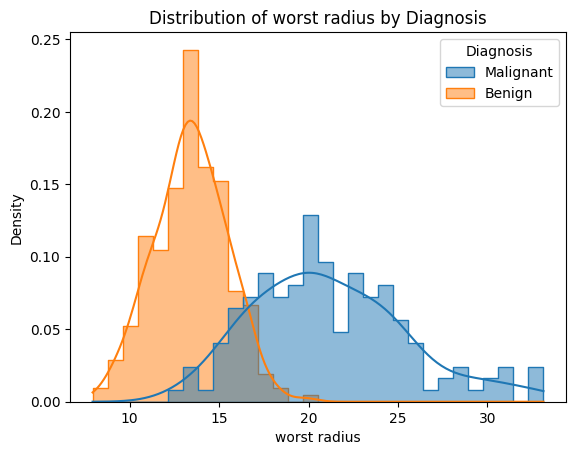

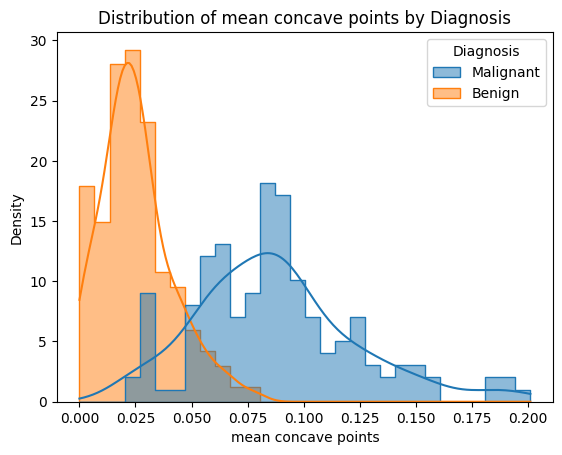

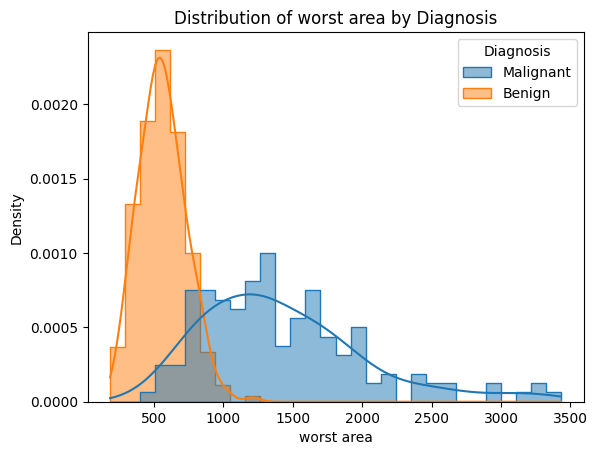

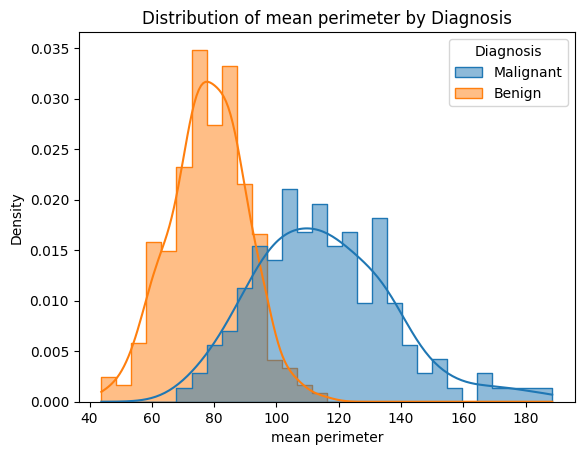

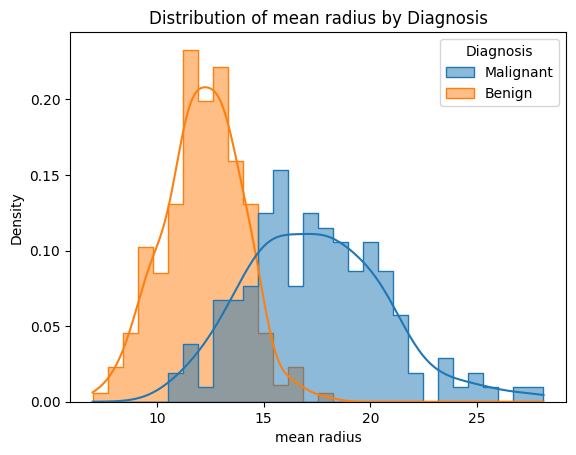

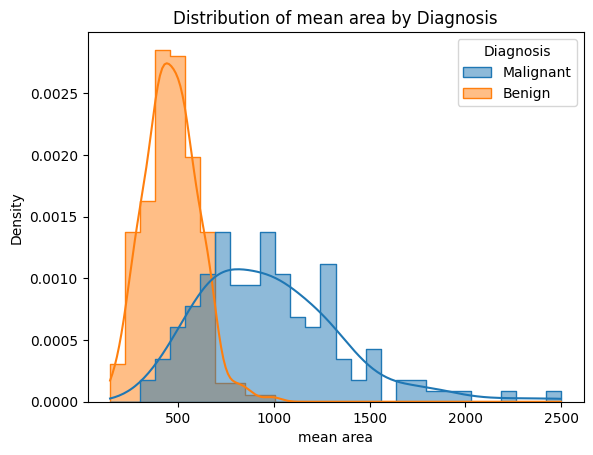

In [40]:
class_seperated_features = target_corr[target_corr.abs()>=0.70].index # upto the lowest corr score of 0.70


for i in class_seperated_features:

  sns.histplot(
      data = full_train_copy,
      x = i,
      hue = "Diagnosis",
      stat = "density", #where observations within each class are concentrated
      common_norm = False, # each class is normalised seperately
      bins = 30,
      alpha = 0.5,
      kde = True,
      element = "step"
  )

  plt.title(f"Distribution of {i} by Diagnosis")
  plt.xlabel(i)
  plt.ylabel("Density")
  plt.show()





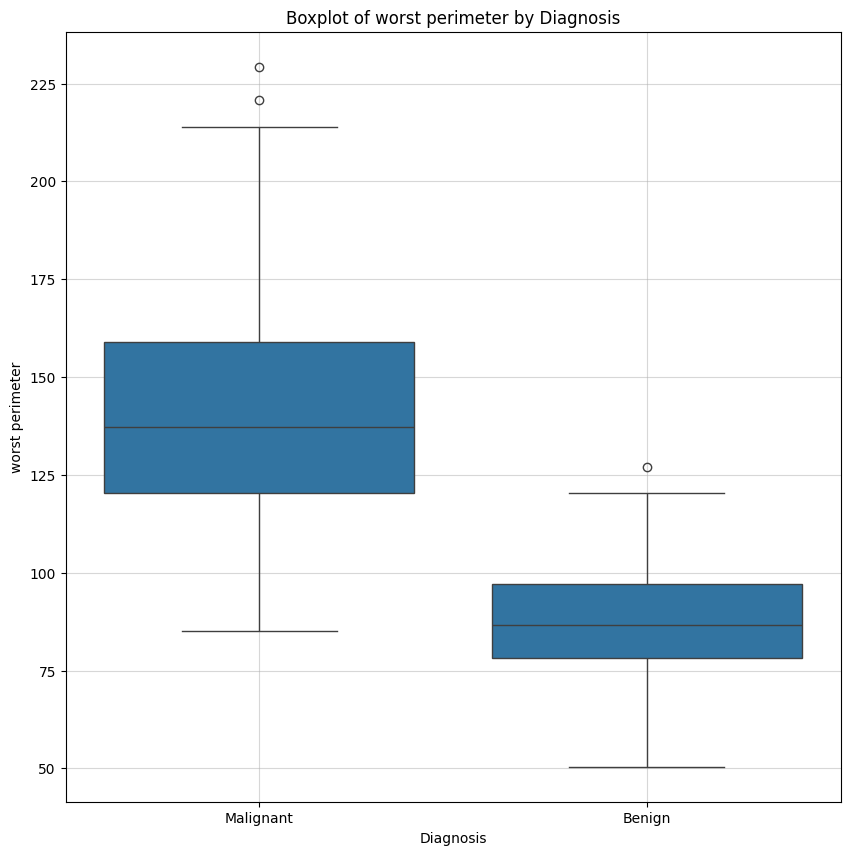

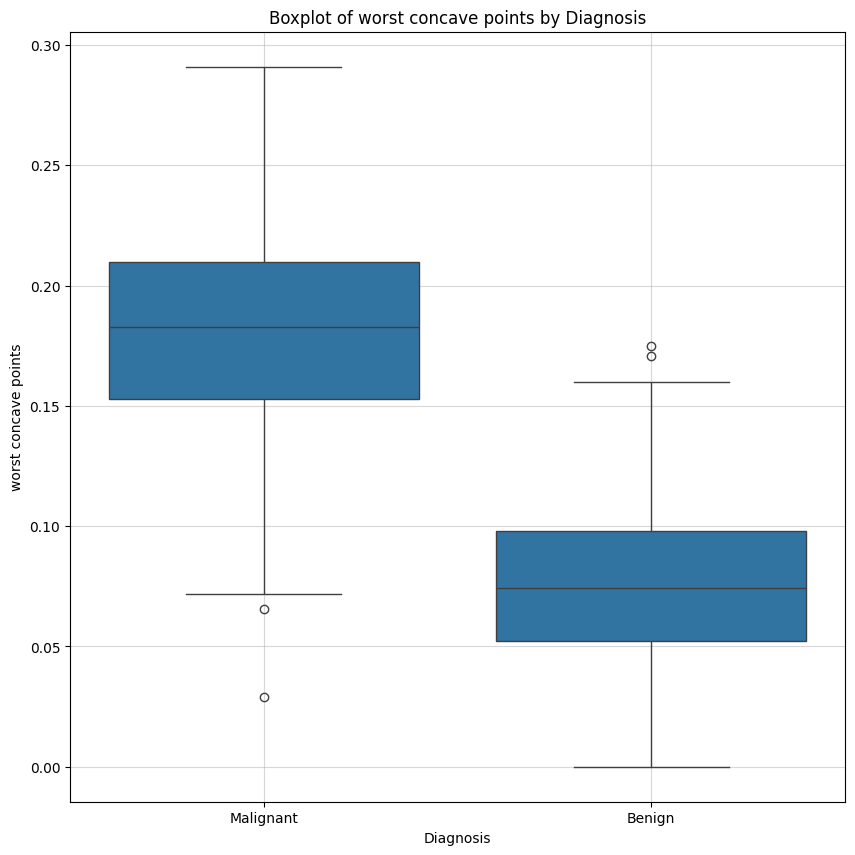

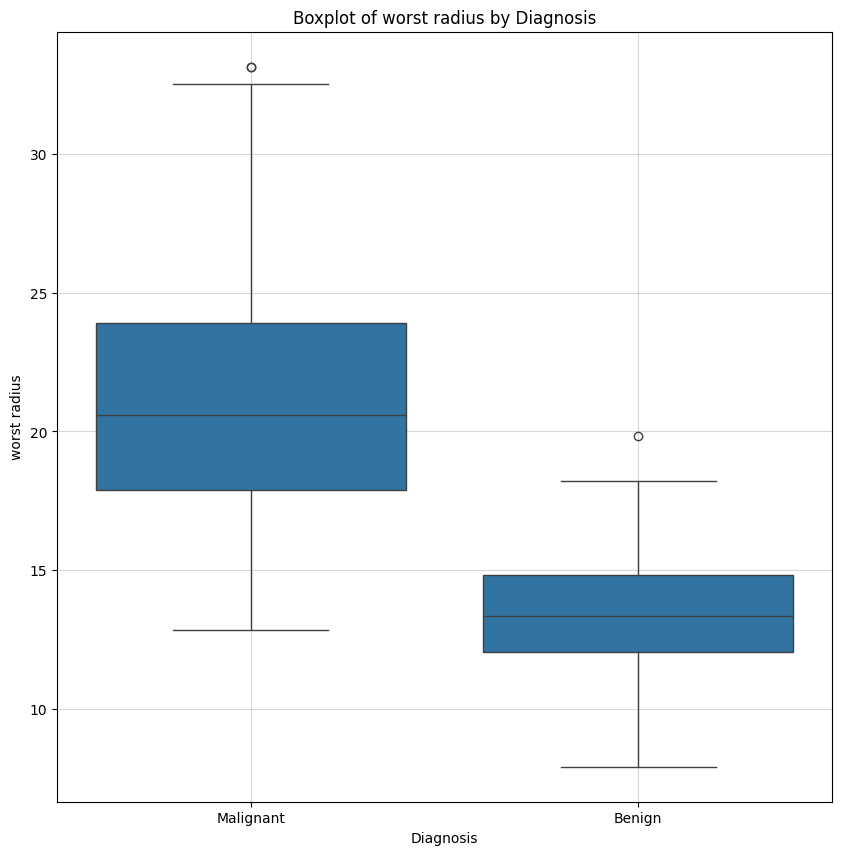

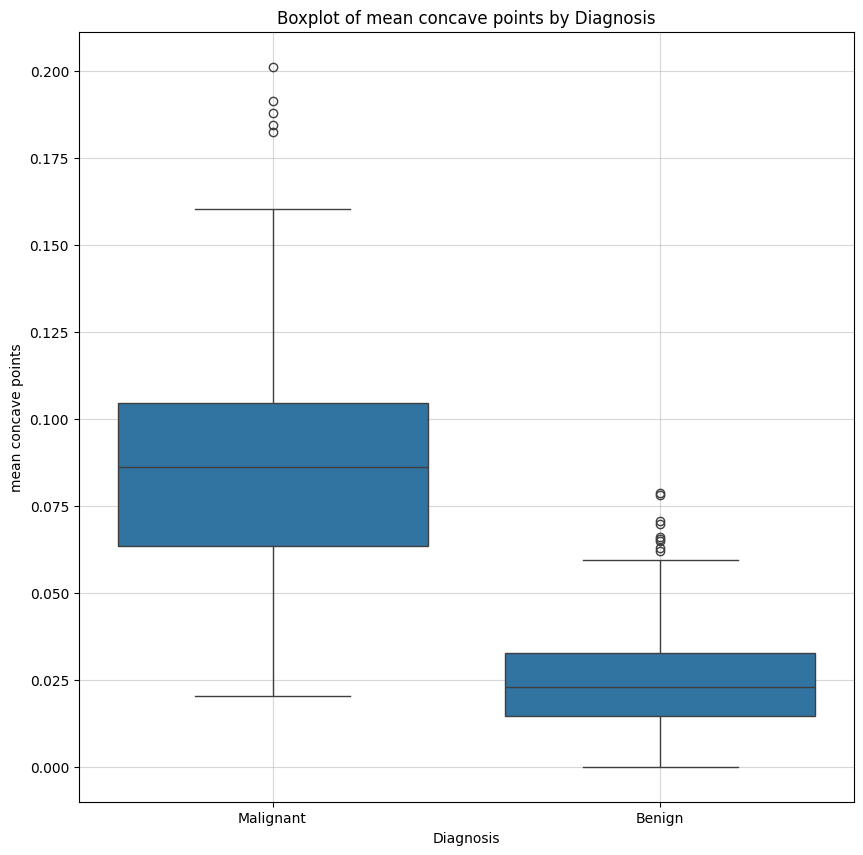

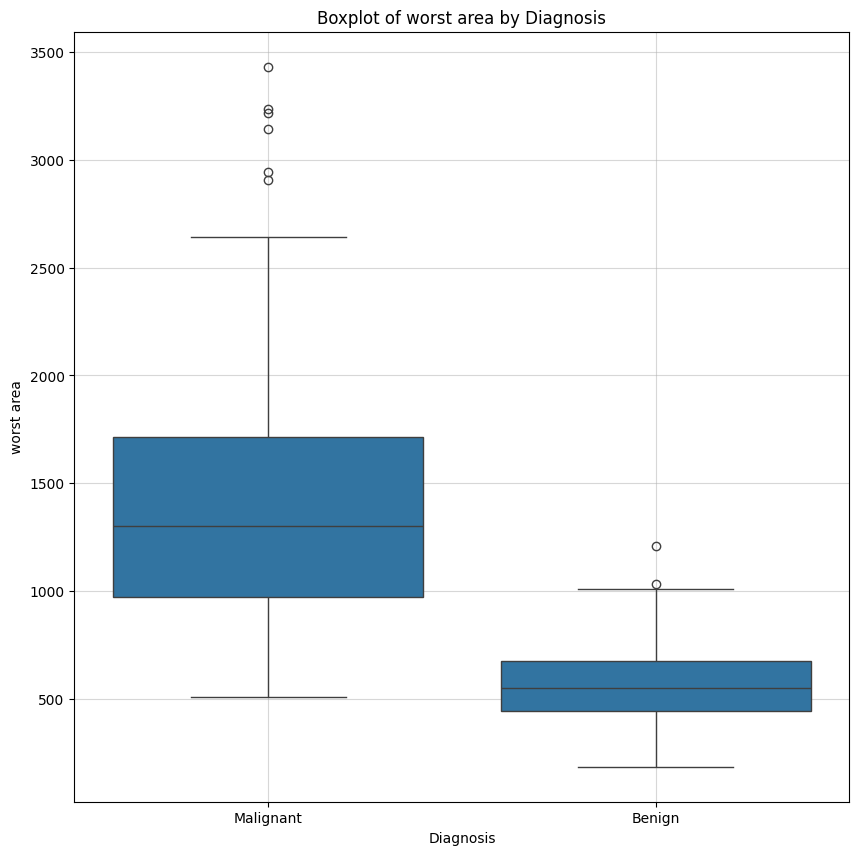

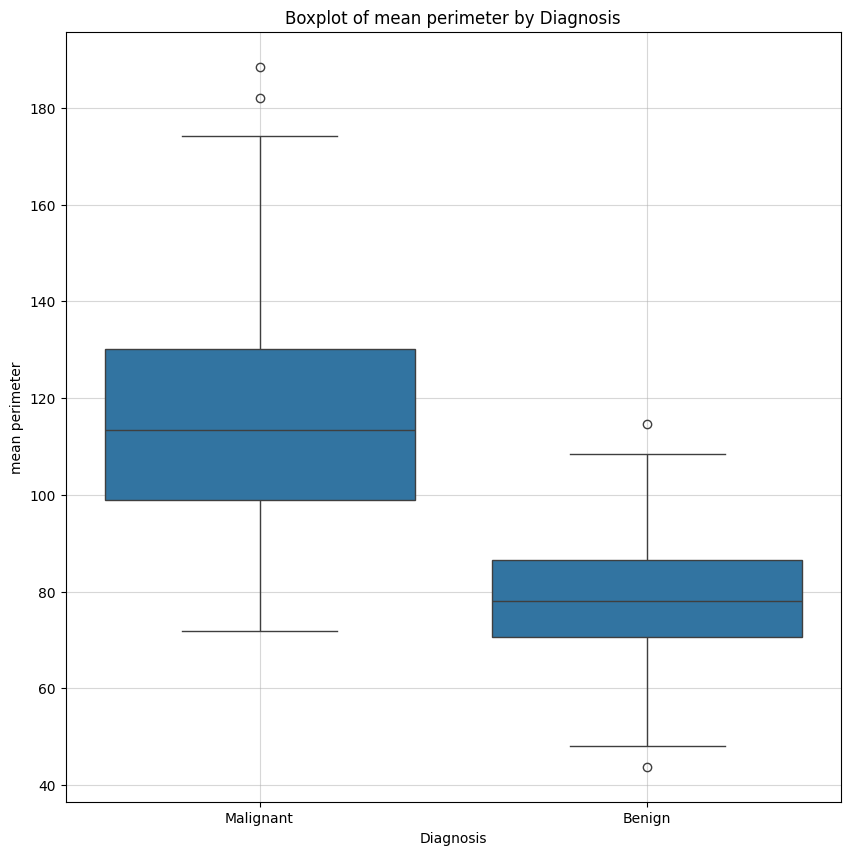

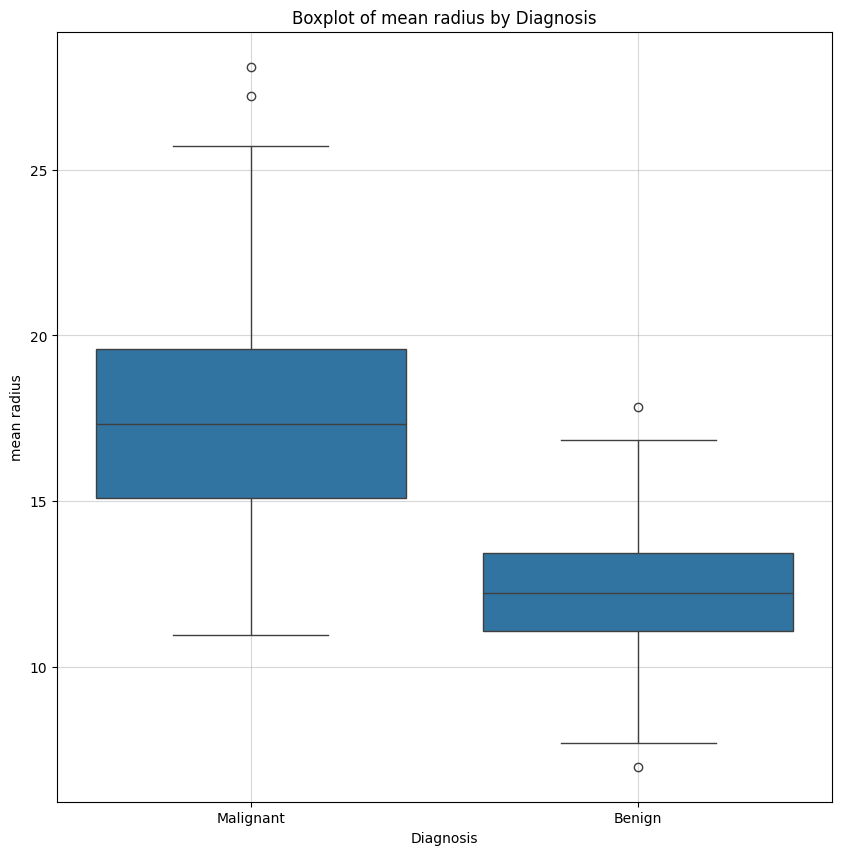

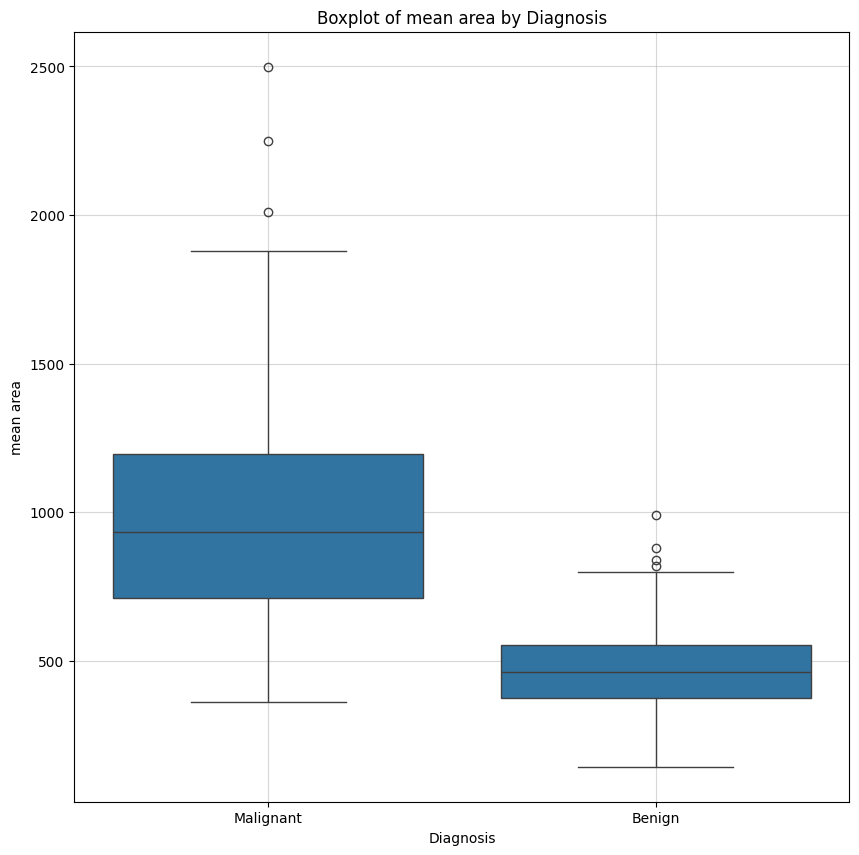

In [41]:
class_seperated_features = target_corr[target_corr.abs()>=0.70].index # upto the lowest corr score of 0.70


for i in class_seperated_features:
  plt.figure(figsize=(10, 10))

  sns.boxplot(
      data = full_train_copy,
      x = "Diagnosis",
      y = i,
  )

  plt.title(f"Boxplot of {i} by Diagnosis")
  plt.xlabel("Diagnosis")
  plt.ylabel(f"{i}")
  plt.grid(True, alpha = 0.5)
  plt.show()


**Pairwise Relationship**
Features to use:


*   Size features (e.g. worst area or worst perimeter, no pint in both as both are related)
*   Irregularity Feature (e.g. concave points)
*   Smoothness or Texture

For each bullet point pick the same type i.e. worst or mean


For each scatter plot
x- axis is one feature
y-axis is another feature
colour = Diagnosis


Look for:

distinct benign and malignant clusters;
regions where the classes overlap;
whether a combination separates classes better than either feature alone;
linear or nonlinear relationships;
extreme observations;
whether two features provide almost identical information.

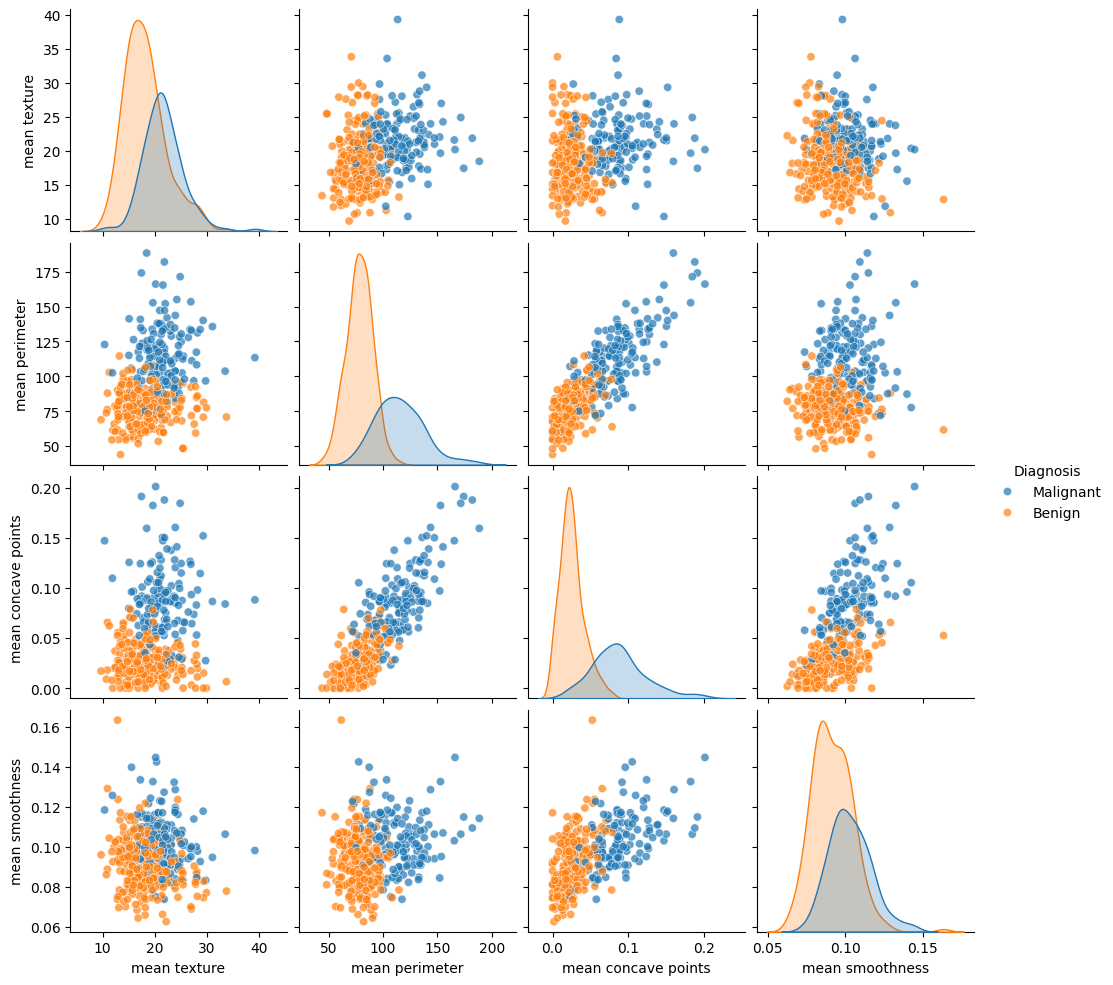

In [42]:
pariplot_features = ["mean texture", "mean perimeter", "mean concave points", "mean smoothness"]

# Create the pairplot
sns.pairplot(
    data = full_train_copy,
    vars= pariplot_features,  # Select the 4 features
    hue='Diagnosis',  # Color by category
    diag_kind='kde',  # KDE plots on the diagonal or hist
    plot_kws={'alpha': 0.7}  # Transparency for scatter points
)


plt.show()

# Exploratory Data Analysis - WriteUp


### Correlation Analysis

The Pearson correlation heatmap revealed several groups of strongly related features. For this analysis, a strong relationship was defined as an absolute correlation coefficient greater than or equal to 0.65.

Measurements describing tumour size showed particularly strong positive correlations. Mean radius, mean perimeter and mean area were highly correlated with one another, as were their corresponding worst-value measurements. Radius error, perimeter error and area error also formed a strongly correlated group.

Strong relationships were additionally observed among compactness, concavity and concave-point measurements. These features describe related aspects of tumour shape and boundary irregularity and may therefore capture overlapping information.

The custom `get_strong_feature_correlations` function was used to create a feature-based lookup containing only relationships that met the specified threshold. The function excluded self-correlations, preserved the original correlation signs and ordered the results by absolute correlation strength.

The number of strong feature-to-feature relationships indicates that the dataset contains substantial redundancy. This may create multicollinearity for linear models and could make individual model coefficients less stable or more difficult to interpret. However, highly correlated features should not be removed automatically; their effect will later be assessed through model performance and, where appropriate, feature-selection experiments.

Correlation with the diagnosis target showed that size- and concavity-related measurements had the strongest positive associations with malignancy. Features including worst perimeter, worst concave points, worst radius, mean concave points and worst area appeared particularly informative. Since malignant tumours were encoded as `1`, positive correlations indicate that larger feature values tend to be associated with malignant cases.




##  Distributions

### Class-Separated Feature Distribution Observations

The selected features generally show that malignant tumours are associated with larger measurements than benign tumours. However, all features contain some degree of class overlap, meaning that none should be considered sufficient for diagnosis in isolation.

**Worst perimeter:** Benign observations are concentrated at lower values, with an estimated density peak around 80–90, while malignant observations peak around 125–140 and have a much wider right-tailed distribution. Meaningful overlap is visible around approximately 95–120. This suggests strong, but imperfect, univariate class separation.

**Worst concave points:** Benign cases are concentrated around approximately 0.07–0.08, while malignant cases are centred closer to 0.18–0.20. Although both classes occupy part of the same overall range, their centres are clearly separated, with the most meaningful overlap occurring around approximately 0.10–0.16. This feature therefore appears potentially informative for distinguishing the classes.

**Worst radius:** Benign cases are generally centred around 13–14, while malignant cases are centred around approximately 20–22. Moderate overlap appears around approximately 15–19. The clear shift between the class distributions suggests strong potential predictive value, although the overlap means that the feature cannot distinguish every observation independently.

**Mean concave points:** The benign distribution peaks around approximately 0.02–0.025, while the malignant distribution peaks near 0.08–0.09. Malignant cases also exhibit a broader distribution and longer right tail. The distributions overlap primarily in the lower-middle range, but their substantially different centres indicate useful class separation.

**Worst area:** Benign observations are concentrated primarily at lower values, whereas malignant observations cover a considerably larger range and extend into a long right tail. Meaningful overlap occurs around approximately 600–1,100. Values toward the upper end of the distribution are predominantly associated with malignant cases.

**Mean perimeter:** Malignant cases are generally shifted toward larger values, while benign cases are concentrated at lower values. Moderate overlap occurs around approximately 80–105. The feature appears informative, although it is also highly correlated with radius and area measurements and may therefore contain redundant information.

**Mean radius:** The benign distribution is centred around approximately 12, whereas the malignant distribution is centred closer to 17. The classes overlap around approximately 13–16, but the malignant distribution is broader and extends toward substantially higher values.

**Mean area:** Benign observations are concentrated at lower areas, while malignant observations have a broader distribution and longer right tail. Moderate overlap occurs around approximately 500–900. Values above approximately 900 are predominantly associated with malignant cases in the training sample, although this should not be interpreted as a validated diagnostic threshold.

Overall, the selected features demonstrate noticeable differences between benign and malignant distributions. Measurements related to tumour size and shape—particularly radius, perimeter, area and concave-point features—appear to provide useful class separation. However, many of these features are strongly correlated with one another, suggesting that they may capture overlapping information rather than independent predictive signals.


### Boxplot Observations by Diagnosis

**Worst perimeter:** The malignant class has a median of approximately 137, compared with approximately 87 for the benign class. The malignant interquartile range extends from roughly 120 to 159, while the benign interquartile range extends from approximately 78 to 97. The boxes do not overlap, indicating clear separation between the central 50% of the two classes. However, the whisker ranges overlap, showing that some individual observations cannot be distinguished using this feature alone. Several potential upper outliers are visible in both classes.

**Worst concave points:** Malignant observations have a median of approximately 0.183, while benign observations have a median around 0.074. The malignant interquartile range is approximately 0.153–0.210, compared with approximately 0.052–0.098 for benign cases. Although the boxes are clearly separated, the whiskers overlap, indicating that some benign and malignant observations occupy similar ranges. Potential outliers appear at both the lower end of the malignant distribution and the upper end of the benign distribution.

**Mean concave points:** The malignant median is approximately 0.086, compared with approximately 0.023 for benign observations. There is minimal overlap between the two boxes, suggesting particularly strong separation between the central distributions of the classes. Both groups contain potential upper outliers, especially the malignant class.

**Worst area:** Malignant observations have a median of approximately 1,300, whereas benign observations have a median around 550. The malignant distribution has a substantially larger interquartile range and overall spread. Although the boxes are largely separated, the malignant lower whisker overlaps with the benign distribution, showing that some malignant tumours have relatively low worst-area values. Several high-value potential outliers are visible, particularly among malignant cases.

Overall, the boxplots show that malignant cases generally have higher medians and wider distributions across all four measurements. The limited overlap between the interquartile ranges suggests useful class separation, while the overlapping whiskers and potential outliers confirm that no individual feature perfectly separates benign and malignant tumours.



### Pairwise Relationship Summary

The pairplot shows that `mean perimeter` and `mean concave points` provide the clearest visual separation between benign and malignant tumours. Benign observations are concentrated mainly at lower values of both features, while malignant observations occur more frequently at higher values. The combination of these two measurements produces more distinct class regions than combinations involving `mean texture` or `mean smoothness`.

`Mean texture` and `mean smoothness` show substantial overlap between the two diagnosis classes and therefore appear to offer weaker class separation individually. In relationships involving these variables, the visible separation is primarily driven by either `mean perimeter` or `mean concave points`.

A strong positive relationship is also visible between `mean perimeter` and `mean concave points`. Although this combination appears useful for distinguishing the classes, the relationship suggests that these features may contain partially overlapping or redundant information. Some mixed regions remain across all feature combinations, confirming that no pair of features perfectly separates benign and malignant cases.






# Exploratory Data Analysis Summary

Exploratory data analysis was conducted using the training set only to prevent information from the test set influencing analytical or modelling decisions.

The stratified train/test split successfully preserved the original class proportions. The training set contained 250 benign cases and 148 malignant cases, resulting in a moderate class imbalance rather than an extreme imbalance.

The individual feature distributions showed substantial differences in scale. Area and perimeter measurements operate over much larger numerical ranges than variables such as smoothness, symmetry and fractal dimension. Several features were also positively skewed and heavy-tailed, with a number of potential extreme observations. These observations support the use of feature scaling for scale-sensitive models such as Logistic Regression, Support Vector Machines and K-Nearest Neighbours. Potential outliers will not be removed automatically because they may represent genuine and clinically informative tumour measurements.

The correlation analysis revealed strong relationships among groups of related measurements. Radius, perimeter and area features were highly correlated, as were several compactness, concavity and concave-point measurements. This indicates that the dataset contains potentially redundant predictors and that multicollinearity may affect the interpretation of linear-model coefficients.

The correlations with diagnosis showed that features describing tumour size and boundary irregularity had the strongest associations with malignancy. Worst perimeter, worst radius, worst area, worst concave points and mean concave points were among the most strongly associated features.

Class-separated histogram and KDE plots showed that malignant tumours generally had larger radius, perimeter, area and concave-point measurements. Their distributions were frequently broader and more right-tailed than those of benign tumours. Although several features displayed strong visual class separation, all contained some degree of overlap, meaning that no individual feature was sufficient for diagnosis in isolation.

The boxplots supported these findings. Malignant cases generally had higher medians and wider interquartile ranges. For several selected features, the benign and malignant boxes showed little or no overlap, although their whiskers and potential outliers overlapped. This indicates clear differences between the central distributions while confirming that individual observations may remain ambiguous.

The pairwise analysis showed that mean perimeter and mean concave points provided the clearest combined visual separation. Benign observations were concentrated predominantly in the lower-value region, while malignant observations occurred more frequently at higher values. Mean texture and mean smoothness showed considerably more class overlap and appeared less discriminative individually.

Overall, the EDA suggests that tumour-size and concavity-related measurements will be important predictors. However, strong feature redundancy, substantial scale differences and remaining class overlap mean that model pipelines, cross-validation and multiple evaluation metrics will be required before deciding which predictors and models perform best.



# Preprocessing + Baseline

(No feature engineering - no domain knowledge + original variables are already engineered)

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [44]:
baseline_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter = 10_000))

])

In [45]:
from sklearn.model_selection import StratifiedKFold, cross_validate

stratified_cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

**Baseline**

In [46]:
scoring_metrics = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [47]:
baseline_cv_metrics = cross_validate(
    estimator = baseline_pipeline,
    X = X_train,
    y = y_train,
    cv = stratified_cv,
    scoring = scoring_metrics,
    return_train_score = True
)

In [48]:
baseline_cv_metrics.keys()

dict_keys(['fit_time', 'score_time', 'test_accuracy', 'train_accuracy', 'test_precision', 'train_precision', 'test_recall', 'train_recall', 'test_f1', 'train_f1', 'test_roc_auc', 'train_roc_auc'])

In [49]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]


baseline_sum = pd.DataFrame({
    "Metric": metrics,
    "Train Mean": [baseline_cv_metrics[f"train_{metric}"].mean() for metric in metrics],
    "Train STD": [baseline_cv_metrics[f"train_{metric}"].std() for metric in metrics],

    "Validation Mean": [baseline_cv_metrics[f"test_{metric}"].mean() for metric in metrics],
    "Validation STD": [baseline_cv_metrics[f"test_{metric}"].std() for metric in metrics]

})


baseline_sum.round(3)

,Metric,Train Mean,Train STD,Validation Mean,Validation STD
0,accuracy,0.988,0.002,0.982,0.006
1,precision,1.000,0.000,1.000,0.000
2,recall,0.968,0.006,0.953,0.017
3,f1,0.984,0.003,0.976,0.009
4,roc_auc,0.998,0.001,0.993,0.006


In [50]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [51]:
baseline_predictions = cross_val_predict(estimator = baseline_pipeline,
                                         X = X_train,
                                         y = y_train,
                                         cv = stratified_cv,
                                         method = "predict")

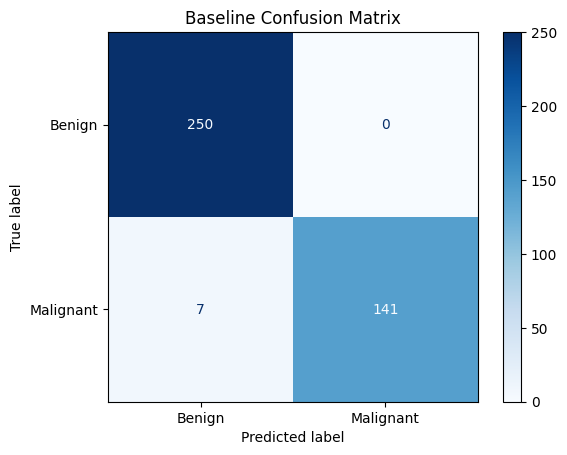

In [52]:
cfm_baseline = confusion_matrix(y_train, baseline_predictions)

cfm_baseline_display = ConfusionMatrixDisplay(cfm_baseline, display_labels = ["Benign", "Malignant"])

cfm_baseline_display.plot(cmap = "Blues", values_format = "d")
plt.title("Baseline Confusion Matrix")
plt.show()

The baseline model achieved strong and stable cross-validation performance. Across the aggregated out-of-fold predictions, all 250 benign cases were classified correctly, while 141 of the 148 malignant cases were correctly identified. Seven malignant cases were incorrectly classified as benign, resulting in a malignant recall of approximately 95.3%. No benign cases were incorrectly classified as malignant, giving the model a malignant precision of 100%. Since false negatives represent the more serious error in this context, reducing the number of missed malignant cases will be the main priority during subsequent model comparison and tuning.


# SVC Pipeline

In [53]:
from sklearn.svm import SVC

svc_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel = "rbf", C=1.0, random_state = 42, gamma = "scale"))

])

In [54]:
SVC_cv_metrics = cross_validate(
    estimator = svc_pipeline,
    X = X_train,
    y = y_train,
    cv = stratified_cv,
    scoring = scoring_metrics,
    return_train_score = True
)

In [55]:

SVC_sum = pd.DataFrame({
    "Metric": metrics,
    "Train Mean": [SVC_cv_metrics[f"train_{metric}"].mean() for metric in metrics],
    "Train STD": [SVC_cv_metrics[f"train_{metric}"].std() for metric in metrics],

    "Validation Mean": [SVC_cv_metrics[f"test_{metric}"].mean() for metric in metrics],
    "Validation STD": [SVC_cv_metrics[f"test_{metric}"].std() for metric in metrics]

})


SVC_sum.round(3)

,Metric,Train Mean,Train STD,Validation Mean,Validation STD
0,accuracy,0.984,0.002,0.972,0.019
1,precision,0.998,0.003,0.979,0.017
2,recall,0.959,0.003,0.946,0.042
3,f1,0.978,0.003,0.961,0.027
4,roc_auc,0.997,0.001,0.993,0.004


In [56]:
SVC_predictions = cross_val_predict(estimator = svc_pipeline,
                                         X = X_train,
                                         y = y_train,
                                         cv = stratified_cv,
                                         method = "predict")

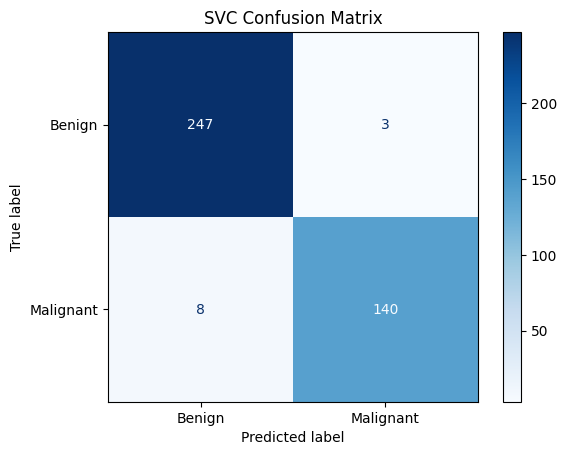

In [57]:
cfm_svc = confusion_matrix(y_train, SVC_predictions)

cfm_svc_display = ConfusionMatrixDisplay(cfm_svc, display_labels = ["Benign", "Malignant"])

cfm_svc_display.plot(cmap = "Blues", values_format = "d")
plt.title("SVC Confusion Matrix")
plt.show()

The untuned SVC classifier achieved slightly worse results than the Logistics Regression baseline model. Although, the model accuracy was good, it produced a total of 11 incorrect predictions which included 3 false positives and 8 false negatives. Includes one extra missed malignant case relative to the Logistic Regression baseline

# Random Forest Pipeline

In [58]:
from sklearn.ensemble import RandomForestClassifier

rfc_pipeline = Pipeline([
    ("classifier", RandomForestClassifier(n_jobs = -1, random_state = 42))

])

In [59]:
rfc_cv_metrics = cross_validate(
    estimator = rfc_pipeline,
    X = X_train,
    y = y_train,
    cv = stratified_cv,
    scoring = scoring_metrics,
    return_train_score = True
)

In [60]:

rfc_sum = pd.DataFrame({
    "Metric": metrics,
    "Train Mean": [rfc_cv_metrics[f"train_{metric}"].mean() for metric in metrics],
    "Train STD": [rfc_cv_metrics[f"train_{metric}"].std() for metric in metrics],

    "Validation Mean": [rfc_cv_metrics[f"test_{metric}"].mean() for metric in metrics],
    "Validation STD": [rfc_cv_metrics[f"test_{metric}"].std() for metric in metrics]

})


rfc_sum.round(3)

,Metric,Train Mean,Train STD,Validation Mean,Validation STD
0,accuracy,1.0,0.0,0.940,0.029
1,precision,1.0,0.0,0.926,0.068
2,recall,1.0,0.0,0.918,0.060
3,f1,1.0,0.0,0.919,0.039
4,roc_auc,1.0,0.0,0.983,0.006


In [61]:
rfc_predictions = cross_val_predict(estimator = rfc_pipeline,
                                         X = X_train,
                                         y = y_train,
                                         cv = stratified_cv,
                                         method = "predict")

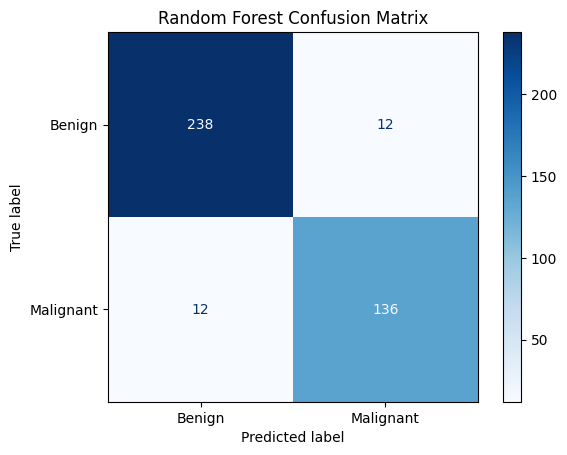

In [62]:
cfm_rfc = confusion_matrix(y_train, rfc_predictions)

cfm_rfc_display = ConfusionMatrixDisplay(cfm_rfc, display_labels = ["Benign", "Malignant"])

cfm_rfc_display.plot(cmap = "Blues", values_format = "d")
plt.title("Random Forest Confusion Matrix")
plt.show()

The untuned Random Forest Classifier overfit the data significantly, producing a training mean of 100%. This was obvioulsy the wrong metric to look at hence the validation metric was inspected and it revealed that the validation mean for all metrics was significantly lower than than both the untuned Baseline Logistic Regression and the untuned SVC metric. Out of the three potential candidates, the Random Forest classifier was the weakest and SVC was the second weakest, leaving the Logistic Regressin model as the strongest. It will be selected for hyperparameter tunning

In [63]:
untuned_metrics = pd.concat([baseline_sum, SVC_sum, rfc_sum], axis = 1)

untuned_metrics.round(3)

,Metric,Train Mean,Train STD,Validation Mean,Validation STD,Metric,Train Mean,Train STD,Validation Mean,Validation STD,Metric,Train Mean,Train STD,Validation Mean,Validation STD
0,accuracy,0.988,0.002,0.982,0.006,accuracy,0.984,0.002,0.972,0.019,accuracy,1.0,0.0,0.940,0.029
1,precision,1.000,0.000,1.000,0.000,precision,0.998,0.003,0.979,0.017,precision,1.0,0.0,0.926,0.068
2,recall,0.968,0.006,0.953,0.017,recall,0.959,0.003,0.946,0.042,recall,1.0,0.0,0.918,0.060
3,f1,0.984,0.003,0.976,0.009,f1,0.978,0.003,0.961,0.027,f1,1.0,0.0,0.919,0.039
4,roc_auc,0.998,0.001,0.993,0.006,roc_auc,0.997,0.001,0.993,0.004,roc_auc,1.0,0.0,0.983,0.006


In [64]:
model_sum = {
    "Logistic Regression (Baseline)": baseline_sum,
    "SVC": SVC_sum,
    "Random Forest": rfc_sum
}



comparison_rows = []


for model, summary in model_sum.items():
  sum_metric = summary.set_index("Metric")

  comparison_rows.append({
      "Model": model,
      "Accuracy Mean": sum_metric.loc["accuracy", "Validation Mean"],
      "Accuracy STD": sum_metric.loc["accuracy", "Validation STD"],

      "Precision Mean": sum_metric.loc["precision", "Validation Mean"],
      "Precision STD": sum_metric.loc["precision", "Validation STD"],

      "Recall Mean": sum_metric.loc["recall", "Validation Mean"],
      "Recall STD": sum_metric.loc["recall", "Validation STD"],


      "F1 Mean": sum_metric.loc["f1", "Validation Mean"],
      "F1 STD": sum_metric.loc["f1", "Validation STD"],


      "ROC-AUC Mean": sum_metric.loc["roc_auc", "Validation Mean"],
      "ROC-AUC STD": sum_metric.loc["roc_auc", "Validation STD"]
  })



untuned_model_comparison = pd.DataFrame(comparison_rows).set_index("Model")

untuned_model_comparison.round(3)

,Accuracy Mean,Accuracy STD,Precision Mean,Precision STD,Recall Mean,Recall STD,F1 Mean,F1 STD,ROC-AUC Mean,ROC-AUC STD
Model,,,,,,,,,,
Logistic Regression (Baseline),0.982,0.006,1.000,0.000,0.953,0.017,0.976,0.009,0.993,0.006
SVC,0.972,0.019,0.979,0.017,0.946,0.042,0.961,0.027,0.993,0.004
Random Forest,0.940,0.029,0.926,0.068,0.918,0.060,0.919,0.039,0.983,0.006


In [65]:
# just the validation means

untuned_model_comparison.loc[:, ["Accuracy Mean", "Precision Mean", "Recall Mean", "F1 Mean", "ROC-AUC Mean"]].round(3)

,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
Model,,,,,
Logistic Regression (Baseline),0.982,1.000,0.953,0.976,0.993
SVC,0.972,0.979,0.946,0.961,0.993
Random Forest,0.940,0.926,0.918,0.919,0.983


### Untuned Model Comparison

Among the three untuned classifiers, Logistic Regression achieved the strongest overall cross-validation performance. It produced the highest validation accuracy, precision, recall and F1-score, while matching the SVC's ROC-AUC of 0.993. Logistic Regression also produced the fewest false negatives and showed greater stability across folds.

The SVC performed strongly but did not improve malignant recall or any other primary validation metric. The Random Forest produced the weakest validation results and substantially overfit the training data. Logistic Regression was therefore selected for hyperparameter tuning.


# Hyperparameter Tuning

In [66]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__C":[0.01, 0.1, 1, 10, 100],
    "classifier__class_weight": [None, "balanced"],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear", "saga"]
}

In [67]:
tuning_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter = 10_000, random_state = 42))

])

In [68]:
log_reg_search = GridSearchCV(
    estimator = tuning_pipeline,
    param_grid = param_grid,
    cv = stratified_cv,
    scoring = scoring_metrics,
    return_train_score = True,
    n_jobs = -1,
    refit = "recall" #tells grtidsearch cv which metric determines the winning hyperparameter
)

In [69]:
log_reg_search.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        LogisticRegression(max_iter=10000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__class_weight': [None, 'balanced'],
                         'classifier__penalty': ['l1', 'l2'],
                         'classifier__solver': ['liblinear', 'saga']},
             refit='recall', return_train_score=True,
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall',
                      'roc_auc': 'roc_auc'})

In [70]:
training_complete_wave = notification(
    event=sound_events["training_complete"],
    sample_rate=sample_rate
)

display(Audio(training_complete_wave, rate=sample_rate, autoplay=True))




In [71]:
log_reg_search.best_params_

{'classifier__C': 1,
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l1',
 'classifier__solver': 'liblinear'}

In [72]:
round(log_reg_search.best_score_, 3)

np.float64(0.966)

In [73]:
log_reg_search.best_index_

np.int64(20)

In [74]:
best = log_reg_search.best_index_

tuned_sum = pd.DataFrame({
    "Metric": metrics,
    "Train Mean": [log_reg_search.cv_results_[f"mean_train_{metric}"][best] for metric in metrics],
    "Train STD": [log_reg_search.cv_results_[f"std_train_{metric}"][best] for metric in metrics],

    "Validation Mean": [log_reg_search.cv_results_[f"mean_test_{metric}"][best] for metric in metrics],
    "Validation STD": [log_reg_search.cv_results_[f"std_test_{metric}"][best] for metric in metrics],


})


tuned_sum.round(3)


,Metric,Train Mean,Train STD,Validation Mean,Validation STD
0,accuracy,0.986,0.003,0.972,0.015
1,precision,0.983,0.007,0.962,0.043
2,recall,0.978,0.004,0.966,0.022
3,f1,0.981,0.004,0.963,0.018
4,roc_auc,0.998,0.001,0.993,0.005


In [75]:
untuned_model_comparison

,Accuracy Mean,Accuracy STD,Precision Mean,Precision STD,Recall Mean,Recall STD,F1 Mean,F1 STD,ROC-AUC Mean,ROC-AUC STD
Model,,,,,,,,,,
Logistic Regression (Baseline),0.982405,0.006176,1.000000,0.000000,0.952644,0.016726,0.975672,0.008806,0.992556,0.006353
SVC,0.972278,0.018664,0.978744,0.017438,0.945517,0.041727,0.961475,0.027271,0.992947,0.004335
Random Forest,0.939620,0.029249,0.925866,0.068032,0.918161,0.060085,0.919054,0.038848,0.983363,0.006401


In [76]:
metric_cols = ["Accuracy Mean", "Precision Mean", "Recall Mean", "F1 Mean", "ROC-AUC Mean"]

tuned_summary = tuned_sum.set_index("Metric")["Validation Mean"]

tuned_model_as_row = pd.DataFrame({
    "Accuracy Mean": [tuned_summary["accuracy"]],
    "Precision Mean": [tuned_summary["precision"]],
    "Recall Mean": [tuned_summary["recall"]],
    "F1 Mean": [tuned_summary["f1"]],
    "ROC-AUC Mean": [tuned_summary["roc_auc"]]
}, index = ["Tuned Logistic Regression"])


tuned_model_as_row

,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
Tuned Logistic Regression,0.972342,0.962431,0.965977,0.963297,0.992561


In [77]:
all_models = pd.concat([untuned_model_comparison[metric_cols], tuned_model_as_row])

all_models.round(3)

,Accuracy Mean,Precision Mean,Recall Mean,F1 Mean,ROC-AUC Mean
Logistic Regression (Baseline),0.982,1.000,0.953,0.976,0.993
SVC,0.972,0.979,0.946,0.961,0.993
Random Forest,0.940,0.926,0.918,0.919,0.983
Tuned Logistic Regression,0.972,0.962,0.966,0.963,0.993


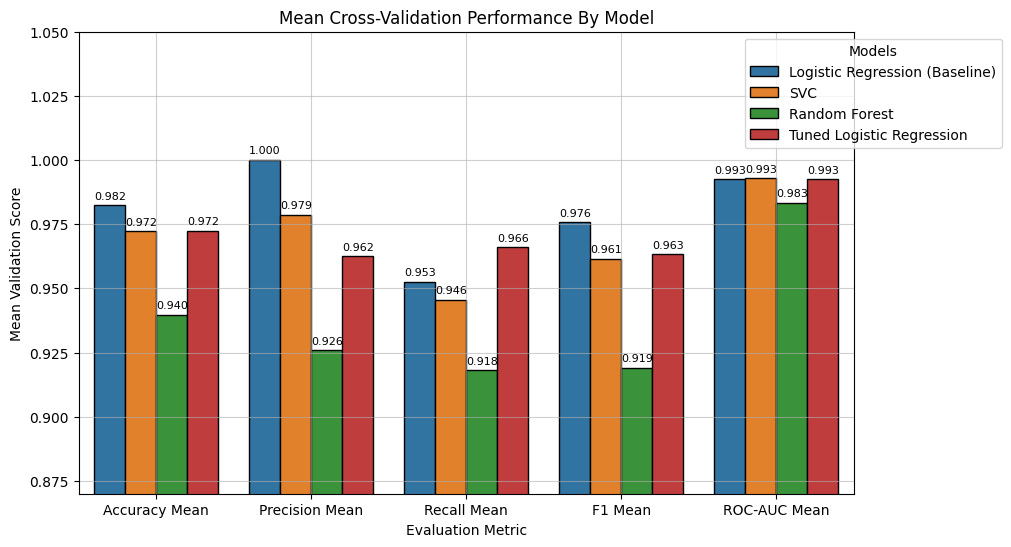

In [78]:
data = (all_models.reset_index(names = "Model")
      .melt(id_vars ="Model",
      var_name="Metric",
      value_name= "Validation Mean"))


plt.figure(figsize = (10,6))

plotter = sns.barplot(
    data = data,
    x= "Metric",
    y = "Validation Mean",
    hue = "Model",
    edgecolor = "black"
)


for plot in plotter.containers:
  plotter.bar_label(plot,
                 fmt = "%.3f",
                 padding = 3,
                 fontsize = 8)

plt.title("Mean Cross-Validation Performance By Model")

plt.xlabel ("Evaluation Metric")
plt.ylabel ("Mean Validation Score")
plt.ylim(0.87,1.05)
plt.legend(title = "Model")
plt.grid(True, alpha = 0.6)
plt.legend(title = "Models", loc = "upper right", bbox_to_anchor = (1.2, 1))
plt.show()




In [79]:
tuned_log_reg = log_reg_search.best_estimator_

tuned_log_reg_predictions = cross_val_predict(estimator = tuned_log_reg,
                                         X = X_train,
                                         y = y_train,
                                         cv = stratified_cv,
                                         method = "predict")

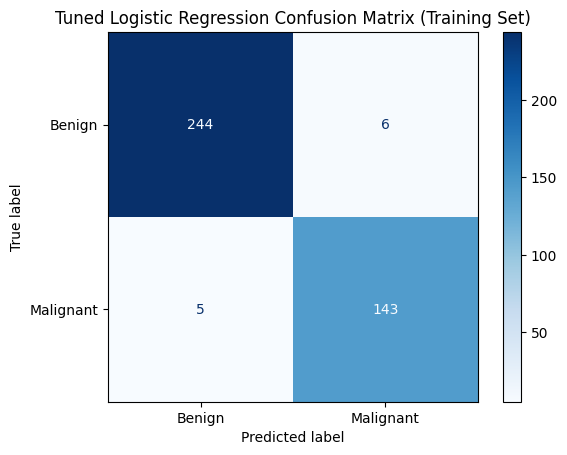

In [80]:
tuned_log_reg_cfm = confusion_matrix(y_train, tuned_log_reg_predictions)

tuned_log_reg_cfm_display = ConfusionMatrixDisplay(tuned_log_reg_cfm, display_labels = ["Benign", "Malignant"])

tuned_log_reg_cfm_display.plot(cmap = "Blues", values_format = "d")
plt.title("Tuned Logistic Regression Confusion Matrix (Training Set)")
plt.show()

In [81]:
tn,fp, fn, tp= tuned_log_reg_cfm.ravel()

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

True Negatives: 244
False Positives: 6
False Negatives: 5
True Positives: 143


The tuned Logistic Regression model reduced the number of false-negative predictions from seven to five, correctly identifying two additional malignant cases. However, this improvement in malignant recall introduced six false-positive predictions, where benign cases were classified as malignant. Consequently, recall increased from approximately 95.3% to 96.6%, while precision, accuracy and F1-score decreased slightly. Since missing a malignant case was treated as the more serious error, the tuned model was selected despite the increase in false-positive predictions.


# Test Set Predictions

In [82]:
predictions = tuned_log_reg.predict(X_test)

In [83]:
test_probs = tuned_log_reg.predict_proba(X_test)[:, 1]

test_probs.round(3)

array([0.142, 0.005, 0.001, 0.004, 0.031, 0.001, 1.   , 0.015, 0.864,
       0.002, 0.022, 1.   , 0.001, 0.001, 0.   , 0.016, 0.001, 1.   ,
       1.   , 1.   , 1.   , 0.38 , 1.   , 0.001, 0.008, 0.981, 1.   ,
       1.   , 0.001, 0.717, 0.896, 0.   , 0.002, 0.887, 0.   , 0.137,
       1.   , 0.988, 0.002, 1.   , 1.   , 0.   , 1.   , 0.   , 0.02 ,
       0.995, 0.569, 0.003, 0.998, 0.001, 0.006, 0.687, 0.001, 0.019,
       0.   , 0.   , 0.065, 0.   , 0.337, 0.978, 0.094, 0.005, 0.017,
       0.994, 1.   , 0.922, 1.   , 0.   , 0.013, 0.   , 0.001, 0.145,
       0.021, 0.006, 1.   , 0.   , 0.025, 1.   , 0.   , 0.108, 0.055,
       0.034, 0.017, 1.   , 0.001, 1.   , 0.001, 0.005, 0.002, 0.004,
       0.   , 0.966, 1.   , 1.   , 1.   , 1.   , 0.001, 0.   , 0.001,
       0.001, 0.055, 1.   , 1.   , 0.003, 0.989, 0.   , 0.996, 1.   ,
       0.   , 1.   , 0.011, 0.929, 0.017, 0.001, 0.998, 0.009, 0.091,
       1.   , 0.   , 0.   , 0.999, 0.998, 0.227, 0.987, 0.   , 0.76 ,
       0.018, 0.013,

In [84]:
test_metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"],
    "Test Score": [accuracy_score(y_test, predictions),
              precision_score(y_test, predictions),
              recall_score(y_test, predictions),
                   f1_score(y_test, predictions),
                   roc_auc_score(y_test, test_probs)]
})

test_metrics.round(3)


,Metric,Test Score
0,Accuracy,0.982
1,Precision,0.984
2,Recall,0.969
3,F1,0.976
4,ROC-AUC,0.998


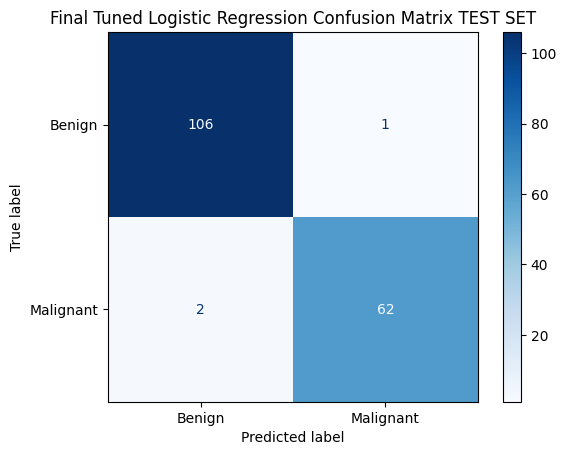

In [85]:
test_cfm = confusion_matrix(y_test, predictions)

test_cfm_display = ConfusionMatrixDisplay(test_cfm, display_labels = ["Benign", "Malignant"])

test_cfm_display.plot(cmap = "Blues", values_format = "d")
plt.title("Final Tuned Logistic Regression Confusion Matrix TEST SET")
plt.show()

In [86]:
tn,fp, fn, tp= test_cfm.ravel()

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

True Negatives: 106
False Positives: 1
False Negatives: 2
True Positives: 62


The final tuned Logistic Regression model achieved an accuracy of 98.2%, precision of 98.4%, malignant recall of 96.9%, an F1-score of 97.6% and a ROC-AUC of 99.8% on the previously unseen test set. Of the 64 malignant cases, 62 were correctly identified, while two were incorrectly classified as benign. Of the 107 benign cases, 106 were correctly classified, with one false-positive prediction. These results indicate strong generalisation performance and demonstrate that the recall-focused tuning strategy maintained high overall predictive performance while limiting the number of missed malignant cases.


# ROC Curve


In [87]:
from sklearn.metrics import roc_curve, auc

test_probs = tuned_log_reg.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

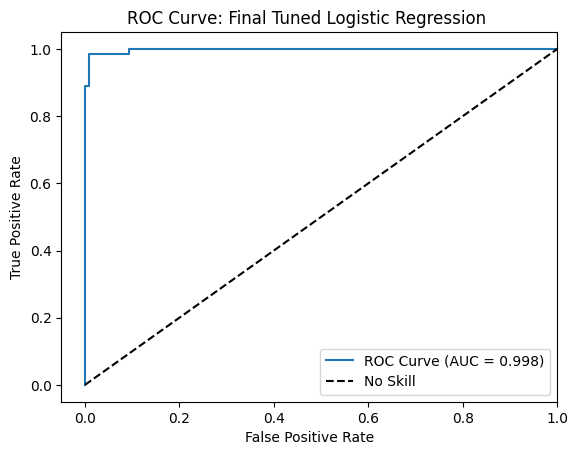

In [88]:
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='No Skill') # Diagonal line for random guessing
plt.xlim([-0.05, 1.0])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Final Tuned Logistic Regression ')
plt.legend(loc="lower right")
plt.show()

In [89]:
final_classifier = tuned_log_reg.named_steps["classifier"]

strengths = pd.Series(
    final_classifier.coef_[0],
    index=X_train.columns
).sort_values()

In [90]:
strengths

,0
compactness error,-1.060438
texture error,-0.600308
fractal dimension error,-0.281117
symmetry error,-0.074680
mean smoothness,0.000000
mean compactness,0.000000
mean radius,0.000000
mean texture,0.000000
area error,0.000000
mean concavity,0.000000


In [91]:
non_zero_strengths = strengths[strengths != 0]

non_zero_strengths

,0
compactness error,-1.060438
texture error,-0.600308
fractal dimension error,-0.281117
symmetry error,-0.074680
worst perimeter,0.120504
worst smoothness,0.242691
smoothness error,0.278713
concave points error,0.340999
worst concave points,0.415472
worst symmetry,0.614000


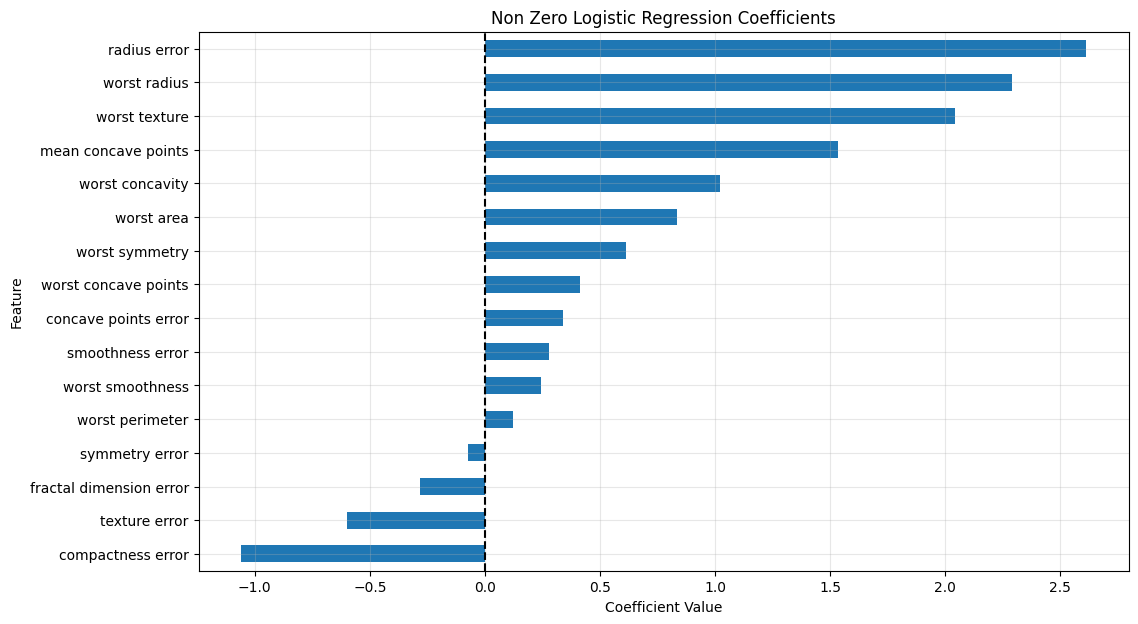

In [92]:
non_zero_strengths.sort_values().plot(kind ="barh", figsize = (12,7))

plt.grid(True, alpha = 0.3)
plt.title("Non Zero Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.axvline( x= 0, color = "black", linestyle = "--")



plt.show()

In [93]:
zero_score_strengths = (strengths == 0).sum()

print(f"Number of Features with Zero Coefficient: {zero_score_strengths}")

zero_score_strengths_table = pd.DataFrame(strengths[strengths == 0]).rename(columns = {0: "Coefficient"})



Number of Features with Zero Coefficient: 14


In [94]:
zero_score_strengths_table

,Coefficient
mean smoothness,0.0
mean compactness,0.0
mean radius,0.0
mean texture,0.0
area error,0.0
mean concavity,0.0
mean fractal dimension,0.0
mean symmetry,0.0
perimeter error,0.0
concavity error,0.0



## Final Results

Following model comparison and hyperparameter tuning, the tuned Logistic Regression model was selected as the final classifier. The selected model used L1 regularisation, balanced class weights, a regularisation parameter of (C=1), and the `liblinear` solver. This configuration was chosen because it produced the highest cross-validation recall for malignant tumours, which was prioritised because incorrectly classifying a malignant tumour as benign represents the more serious error.

During cross-validation, tuning increased malignant recall from approximately 95.3% to 96.6%. This reduced the number of false-negative predictions from seven to five. However, the improved recall introduced six false-positive predictions and caused small reductions in accuracy, precision and F1-score. The tuned model was therefore selected as a recall-focused trade-off rather than as an improvement across every evaluation metric.

The final model was then evaluated once on the previously unseen test set containing 171 observations. It achieved the following results:

| Metric    | Test Score |
| --------- | ---------: |
| Accuracy  |      0.982 |
| Precision |      0.984 |
| Recall    |      0.969 |
| F1-score  |      0.976 |
| ROC-AUC   |      0.998 |

The test-set confusion matrix contained:

* 106 true negatives
* 1 false positive
* 2 false negatives
* 62 true positives

The model correctly classified 168 of the 171 test observations. Of the 64 malignant tumours, 62 were correctly identified, giving a malignant recall of approximately 96.9%. Two malignant tumours were incorrectly classified as benign. Of the 107 benign tumours, 106 were correctly identified, while one was incorrectly classified as malignant.

The ROC-AUC score of 0.998 indicates that the model demonstrated excellent ability to distinguish between benign and malignant tumours across different classification thresholds. The strong agreement between the cross-validation and final test-set results also suggests that the model generalised well to unseen observations and did not show substantial evidence of overfitting.

Overall, the tuned Logistic Regression model achieved strong predictive performance while maintaining the project's emphasis on reducing missed malignant cases. Nevertheless, these results were obtained from a relatively small benchmark dataset and should not be interpreted as evidence that the model is suitable for real-world clinical diagnosis without further external validation.

